# Total precipitation comparisons

This notebook will compare the following for the relevant instruments:

(1) Compare all instruments with observations spanning the entire timeseries defined as October 1, 2021 - June 16, 2023

(2) Compare totals for relevant instruments during water year 2022 and the times during water year 2023

(3) Compare totals for each season (SON, DJF, MAM, JJA) with the relevant instruments

In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from utils.helper_funcs import TaylorDiagram

## Functions

For organizing data

In [2]:
def get_dataset(site, directory, time_slice=None):
    """Load dataset for a given site."""
    # precipitation datasets
    gothic_prcp_ds = xr.open_dataset(directory / f'{site}_precipitation_30min.nc')
    era5_land_prcp_ds = xr.open_dataset(directory / f'ERA5-Land/era5_land_gothic_1hr.nc')
    prism_prcp_ds = xr.open_dataset(directory / f'PRISM/prism_site_data.nc').sel(site=site)
    # merge datasets
    ds = xr.merge([gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds], compat='override')
    if time_slice is not None:
        ds = ds.sel(time=time_slice)
    # rename tp to ERA5-Land and ppt to PRISM for clarity
    ds = ds.rename({'tp':'ERA5-Land', 'ppt':'PRISM'})
    # drop crs datavar if it exists
    if 'crs' in ds.data_vars:
        ds = ds.drop_vars('crs')
    return ds

def get_relevant_dates(ds, analysis_type='all', water_year=None, gridded=False):
    
    """Get the relevant start and end dates for analysis based on data availability.
    Parameters:
        ds (xarray.Dataset): The dataset containing the data variables.
        analysis_type (str): Type of analysis ('all', 'warm', 'cold').
        water_year (int): The water year for seasonal analysis (e.g., 2023 for Oct 2022 - Sep 2023).
    """
    # for each datavar, get the time series of the first and last non-nan values
    starts = []
    ends = []
    for var in ds.data_vars:
        data = ds[var]
        first_valid_index = data.to_series().first_valid_index()
        last_valid_index = data.to_series().last_valid_index()
        starts.append((var, first_valid_index))
        ends.append((var, last_valid_index))

    # find the latest start time and the earliest end time after June 1, 2023
    if (analysis_type == 'all' and water_year is None) or (gridded and analysis_type == 'all'):
        latest_start = max(start[1] for start in starts if start[1] <= pd.Timestamp("2021-10-01"))
        if gridded:
            earliest_end = min(end[1] for end in ends if end[1] >= pd.Timestamp("2023-09-30"))
        else:
            earliest_end = pd.Timestamp("2023-06-12")
    elif analysis_type == 'warm':
        if water_year is None:
            raise ValueError("water_year must be specified for warm season analysis.")
        latest_start = pd.Timestamp(f"{water_year}-05-01") ### Warm season starts May 1 of previous calendar year
        earliest_end = pd.Timestamp(f"{water_year}-10-31")
    elif analysis_type == 'cold':
        if water_year is None:
            raise ValueError("water_year must be specified for cold season analysis.")
        latest_start = pd.Timestamp(f"{water_year-1}-11-01")
        earliest_end = pd.Timestamp(f"{water_year}-04-30")
    elif analysis_type == 'DJF':
        if water_year is None:
            raise ValueError("water_year must be specified for DJF analysis.")
        latest_start = pd.Timestamp(f"{water_year-1}-12-01")
        earliest_end = pd.Timestamp(f"{water_year}-02-28")
    elif analysis_type == 'MAM':
        if water_year is None:
            raise ValueError("water_year must be specified for MAM analysis.")
        latest_start = pd.Timestamp(f"{water_year}-03-01")
        earliest_end = pd.Timestamp(f"{water_year}-05-31")
    elif analysis_type == 'JJA':
        if water_year is None:
            raise ValueError("water_year must be specified for JJA analysis.")
        latest_start = pd.Timestamp(f"{water_year}-06-01")
        earliest_end = pd.Timestamp(f"{water_year}-08-31")
    elif analysis_type == 'SON':
        if water_year is None:
            raise ValueError("water_year must be specified for SON analysis.")
        latest_start = pd.Timestamp(f"{water_year}-09-01")
        earliest_end = pd.Timestamp(f"{water_year}-11-30")
    elif analysis_type == 'all' and water_year == 2022:
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-09-30")
    elif analysis_type == 'all' and water_year == 2023:
        latest_start = pd.Timestamp(f"{water_year-1}-10-01")
        earliest_end = pd.Timestamp(f"{water_year}-06-12")
    else:
        raise ValueError("Invalid combination of analysis_type and water_year. Only 2022 and 2023 water years are supported for seasonal analyses.")

    time_slice = slice(latest_start, earliest_end)  # instrument data range
    return time_slice

def drop_bad_or_irrelevant_vars(ds, nan_threshold=0.8):
    """Drop variables with known data quality issues or irrelevant to the analysis."""
    bad_vars = ['sail_pwd_rain', 'sail_squire_rain','sail_tbg_corr', 'rain_rate_A']  # example bad vars
    gridded_vars = ['ERA5-Land','PRISM']  # keep these regardless of nans
    for var in ds.data_vars:
        if var in ds.data_vars:
            if var in bad_vars:
                ds = ds.drop_vars(var)
            elif var in gridded_vars:
                continue  # keep gridded vars
            else:
                # calculate number of nans in variable
                nan_count = ds[var].isnull().sum().item()
                if (nan_count / ds.sizes['time']) > nan_threshold:  # if more than 80% nans, drop variable
                    ds = ds.drop_vars(var)
        else:
            continue
    return ds

For plotting

In [3]:
def matplotlib_cmap():
    colors_20 = [
    "#1E90FF", "#FF4500", "#32CD32", "#9400D3", "#FFD700",
    "#00CED1", "#DC143C", "#228B22", "#4169E1", "#FF8C00",
    "#8A2BE2", "#3CB371", "#C71585", "#2E8B57", "#DAA520",
    "#6495ED", "#CD5C5C", "#20B2AA", "#BA55D3", "#B8860B"
    ]
    from matplotlib.colors import ListedColormap
    cmap_20 = ListedColormap(colors_20, name="high_separation_20")      
    return cmap_20

def plotly_cmap():
    colors_20 = [
    "#1E90FF", "#FF4500", "#32CD32", "#9400D3", "#FFD700",
    "#00CED1", "#DC143C", "#228B22", "#4169E1", "#FF8C00",
    "#8A2BE2", "#3CB371", "#C71585", "#2E8B57", "#DAA520",
    "#6495ED", "#CD5C5C", "#20B2AA", "#BA55D3", "#B8860B"
    ]
    return colors_20

In [4]:
def plot_accumulated_precipitation(ds, plot_lib, site, analysis_type, water_year, legend=False):
    """Plot accumulated precipitation from different datasets."""
    if plot_lib not in ['plt', 'matplotlib', 'plotly']:
        raise ValueError("plot_lib must be either 'plt', 'matplotlib', or 'plotly'.")
    plt_title = f"Accumulated Precipitation at {site.title()} Site"
    if analysis_type in ['warm', 'cold'] and water_year is not None:
        plt_title += f" ({analysis_type.title()} Season {water_year})"
    elif analysis_type == 'all' and water_year is not None:
        plt_title += f" (Water Year {water_year})"
    
    if plot_lib in ['plt', 'matplotlib']:
        plt.style.use('seaborn-v0_8-talk')
        fig = plt.figure(figsize=(10,6))
        benchmark_color = 'red'
        colors = matplotlib_cmap()
        for var, color in zip(ds.data_vars, colors.colors):
            label = var.replace('_', ' ').title()
            accumulated_prcp = ds[var].cumsum(dim='time', skipna=True)
            if var == 'billy_barr_precip':
                label = 'Benchmark (billy barr)'
                color = benchmark_color
            elif var in ['ERA5-Land', 'PRISM']:
                label = var 
            else:
                label = var.replace('_', ' ').title()

            # also include the last value greater than 0
            try:
                last_positive_index = ds[var].where(ds[var] > 0, drop=True).time.values[-1]
                # if last_valid_index is less than 12 days before the end, skip plotting
                time_delta = ds['time'].values[-1] - last_positive_index
                # convert to time delta in days
                days_delta = time_delta / np.timedelta64(1, 'D')
            except:
                last_positive_index = None
    
            if last_positive_index is None or days_delta > 30:
                continue

            plt.plot(ds['time'], accumulated_prcp, label=label, color=color, lw=2)
            # add small text label next to max value
            max_time = ds['time'].values[-1]
            max_value = accumulated_prcp.values[-1]
            plt.text(max_time, max_value, label, color=color, fontsize=14, va='center', ha='left')
        plt.axhline(0, color='black', lw=2, ls='-')
        # rotate x-ticks for better readability
        plt.xticks(rotation=45)
        plt.title(plt_title)
        plt.xlabel('Time')
        plt.ylabel('Accumulated Precipitation (mm)')
        if legend:
            plt.legend()
        plt.grid()
    elif plot_lib == 'plotly':
        fig = go.Figure()
        benchmark_color = 'red'
        colors = plotly_cmap()
        for color, var in zip(colors, ds.data_vars):
            accumulated_prcp = ds[var].cumsum(dim='time', skipna=True)
            if var == 'billy_barr_precip':
                label = 'Benchmark (billy barr)'
                color = benchmark_color
            else:
                label = var.replace('_', ' ').title()
            
            # also include the last value greater than 0
            try:
                last_positive_index = ds[var].where(ds[var] > 0, drop=True).time.values[-1]
                # if last_valid_index is less than 12 days before the end, skip plotting
                time_delta = ds['time'].values[-1] - last_positive_index
                # convert to time delta in days
                days_delta = time_delta / np.timedelta64(1, 'D')
            except:
                last_positive_index = None
    
            if last_positive_index is None or days_delta > 30:
                continue
            
            fig.add_trace(go.Scatter(x=ds['time'].values, y=accumulated_prcp.values, mode='lines', name=label, line=dict(color=color, width=2)))
            # add small text label next to max value
            max_time = ds['time'].values[-1]
            max_value = accumulated_prcp.values[-1]
            fig.add_annotation(x=max_time, y=max_value, text=label, showarrow=False, font=dict(size=14), xanchor='left', yanchor='middle')
        fig.add_hline(y=0, line_color='black', line_width=2)
        if legend:
            fig.update_layout(showlegend=True)
        else:
            fig.update_layout(showlegend=False)
        fig.update_layout(title=plt_title,
                          xaxis_title='Time',
                          yaxis_title='Accumulated Precipitation (mm)',
                          template='plotly_white',
                          width=800,
                          height=500)
        # add gridlines
        fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
        fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
        # increase font size
        fig.update_layout(font=dict(size=16))
    return fig

In [5]:
def plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=None, analysis_type='all', water_year=None, legend=False, gridded=False):
    """Plot accumulated bias of different datasets against a benchmark."""
    if plot_lib not in ['plt', 'matplotlib', 'plotly']:
        raise ValueError("plot_lib must be either 'plt', 'matplotlib', or 'plotly'.")
    plt_title = f"Accumulated Precipitation Bias at {site.title()} Site"
    
    if analysis_type in ['warm', 'cold'] and water_year is not None:
        plt_title += f" ({analysis_type.title()} Season {water_year})"
    elif analysis_type == 'all' and water_year is not None:
        plt_title += f" (Water Year {water_year})"
    
    if benchmark not in ds.data_vars:
        raise ValueError(f"Benchmark variable '{benchmark}' not found in dataset.")
    
    if not gridded:
        ds = ds.drop_vars(['ERA5-Land', 'PRISM'], errors='ignore')

    if plot_lib in ['plt', 'matplotlib']:
        # Combine them
        colors = matplotlib_cmap()
        plt.style.use('seaborn-v0_8-talk')
        fig = plt.figure(figsize=(10,6))
        for var, color in zip(ds.data_vars, colors.colors):
            if var == benchmark:
                continue  # skip benchmark
            label = var.replace('_', ' ').title()
            bias = ds[var] - ds[benchmark]
            accumulated_bias = bias.cumsum(dim='time', skipna=True)

            # also include the last value greater than 0
            try:
                last_positive_index = ds[var].where(ds[var] > 0, drop=True).time.values[-1]
                # if last_valid_index is less than 12 days before the end, skip plotting
                time_delta = ds['time'].values[-1] - last_positive_index
                # convert to time delta in days
                days_delta = time_delta / np.timedelta64(1, 'D')
            except:
                last_positive_index = None
    
            if last_positive_index is None or days_delta > 30:
                continue
            plt.plot(ds['time'], accumulated_bias, label=label, color=color, lw=2)
            # add small text label next to max value
            max_time = ds['time'].values[-1]
            max_value = accumulated_bias.values[-1]
            plt.text(max_time, max_value, label, color=color, fontsize=14, va='center', ha='left')
        plt.axhline(0, color='black', lw=2, ls='-')
        # rotate x-ticks for better readability
        plt.xticks(rotation=45)
        plt.title(plt_title)
        plt.xlabel('Time')
        plt.ylabel('Accumulated Precipitation Bias (mm)')
        if legend:
            plt.legend()
        plt.grid()
        return fig
    elif plot_lib == 'plotly':
        fig = go.Figure()
        colors = plotly_cmap()
        for color, var in zip(colors, ds.data_vars):
            if var == benchmark:
                continue  # skip benchmark
            bias = ds[var] - ds[benchmark]
            accumulated_bias = bias.cumsum(dim='time', skipna=True)
            label = var.replace('_', ' ').title()
            
            # also include the last value greater than 0
            try:
                last_positive_index = ds[var].where(ds[var] > 0, drop=True).time.values[-1]
                # if last_valid_index is less than 12 days before the end, skip plotting
                time_delta = ds['time'].values[-1] - last_positive_index
                # convert to time delta in days
                days_delta = time_delta / np.timedelta64(1, 'D')
            except:
                last_positive_index = None
    
            if last_positive_index is None or days_delta > 30:
                continue

            fig.add_trace(go.Scatter(x=ds['time'].values, y=accumulated_bias.values, mode='lines', name=label, line=dict(color=color, width=2)))
            # add small text label next to max value
            max_time = ds['time'].values[-1]
            max_value = accumulated_bias.values[-1]
            fig.add_annotation(x=max_time, y=max_value, text=label, showarrow=False, font=dict(size=14), xanchor='left', yanchor='middle')
        fig.add_hline(y=0, line_color='black', line_width=2)
        if legend:
            fig.update_layout(showlegend=True)
        else:
            fig.update_layout(showlegend=False)
        fig.update_layout(title=plt_title,
                          xaxis_title='Time',
                          yaxis_title='Accumulated Precipitation Bias (mm)',
                          template='plotly_white',
                          width=800,
                          height=500)
        # add gridlines
        fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
        fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')
        # increase font size
        fig.update_layout(font=dict(size=16))
        return fig

In [6]:
def plot_taylor_diagram(ds, benchmark):
    ds_resampled = ds.resample(time='1D').sum()
    ref = ds_resampled[benchmark].reset_coords(drop=True).values
    ref_std = np.std(ref, ddof=1)

    fig = plt.figure(figsize=(8, 8))
    td = TaylorDiagram(ref, fig)
    colors = matplotlib_cmap().colors

    # Add samples
    for i, var in enumerate(ds_resampled.data_vars):
        if var == 'billy_barr_precip':
            continue  # skip benchmark
        td.add_sample(ds_resampled[var], label=var.replace('_', ' ').title(), color=colors[i])

    # Add RMS curves
    levels = np.arange(1, 6, 1)
    td.add_rms_curves(levels, color='0.5', ls='--')
    td.add_bias_circle()

    plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1))
    plt.ylim(0, 10)
    return fig

In [7]:
def save_figure(fig, site, analysis_type, water_year, plot_type, plot_lib, gridded, output_dir):
    """Save the figure to the specified output directory."""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    if gridded:
        site += '_gridded'
    if analysis_type in ['warm', 'cold'] and water_year is not None:
        filename = f"{site}_{analysis_type}_season_{water_year}_prcp_{plot_type}.png"
    elif analysis_type == 'all' and water_year is not None:
        filename = f"{site}_{water_year}_prcp_{plot_type}.png"
    else:
        filename = f"{site}_all_data_prcp_{plot_type}.png"
    filepath = os.path.join(output_dir, filename)
    if plot_lib in ['plt', 'matplotlib']:
        fig.savefig(filepath, bbox_inches='tight')
    elif plot_lib == 'plotly':
        fig.write_image(filepath)
    print(f"Figure saved to {filepath}")

## Data

In [8]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed/final/")
OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/")
TABLE_OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/tables/")
GRIDDED_VARS = ['ERA5-Land','PRISM','billy_barr_precip']

# billy barr data comparison and evaluation

Here we compary billy's precipitation gauge to his manual measurements over the time period of interest.

In [9]:
bb_station_data = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_20211001-20230930_30min.nc")
bb_manual_data = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/billy_barr/billy_barr_manual_data.nc").sortby('datetime')

# rename time to datetime for bb_manual_data
bb_manual_data = bb_manual_data.rename({'datetime':'time'})

In [10]:
time_slice = slice("2021-10-01", "2023-06-30")
bb_station_ppt_sum = bb_station_data['precip'].sel(time=time_slice).resample(time='3D').sum().to_series()
bb_manual_ppt_sum = bb_manual_data['rain'].sel(time=time_slice).resample(time='3D').sum().to_series()
bb_manual_ppt_sum = bb_manual_ppt_sum[~bb_manual_ppt_sum.index.duplicated(keep='last')]
bb_manual_swe_sum = bb_manual_data['SWE'].sel(time=time_slice).resample(time='3D').sum().to_series()
bb_manual_swe_sum = bb_manual_swe_sum[~bb_manual_swe_sum.index.duplicated(keep='last')]

bb_comparison_df = pd.DataFrame({
    'Station_Precipitation_mm': bb_station_ppt_sum,
    'Manual_Rain_mm': bb_manual_ppt_sum*10,
    'Manual_SWE_mm': bb_manual_swe_sum*10
})

bb_comparison_df['Total_Manual_Precipitation_mm'] = bb_comparison_df['Manual_Rain_mm'].fillna(0) + bb_comparison_df['Manual_SWE_mm'].fillna(0)

# remove any values above 100 mm in a day as likely errors
bb_comparison_df = bb_comparison_df[bb_comparison_df['Station_Precipitation_mm'] <= 100]
bb_comparison_df = bb_comparison_df[bb_comparison_df['Total_Manual_Precipitation_mm'] <= 100]

# remove days when manual precipitation is zero but station precipitation is greater than zero
bb_comparison_df = bb_comparison_df[~((bb_comparison_df['Total_Manual_Precipitation_mm'] == 0) & (bb_comparison_df['Station_Precipitation_mm'] > 0))]

bb_comparison_rain_only_df = bb_comparison_df[~((bb_comparison_df['Manual_SWE_mm'] > 0))].dropna()

bb_comparison_snow_only_df = bb_comparison_df[~((bb_comparison_df['Manual_Rain_mm'] > 0))].dropna()

In [11]:
resample_r_value = {}
for resample in ['1D', '2D', '3D', '5D', '7D']:
    df = bb_comparison_df.resample(resample).sum()
    # calculate r value
    if len(df) > 0:
        r_value = df['Station_Precipitation_mm'].corr(df['Total_Manual_Precipitation_mm'])**2
        resample_r_value[resample] = r_value

Text(0, 0.5, 'Station Precipitation (mm)')

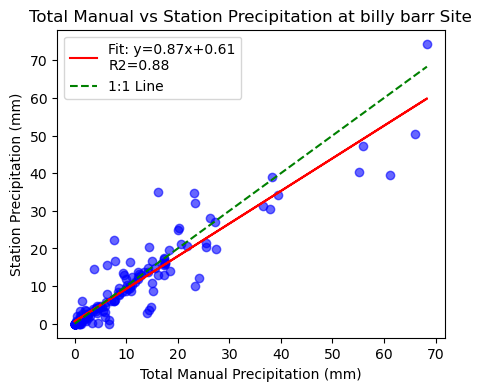

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(bb_comparison_df['Total_Manual_Precipitation_mm'], bb_comparison_df['Station_Precipitation_mm'], color='blue', alpha=0.6)

slope, intercept, r_value, p_value, std_err = stats.linregress(bb_comparison_df['Total_Manual_Precipitation_mm'], bb_comparison_df['Station_Precipitation_mm'])

ax.plot(bb_comparison_df['Total_Manual_Precipitation_mm'], intercept + slope*bb_comparison_df['Total_Manual_Precipitation_mm'], 'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}\nR2={r_value**2:.2f}')
ax.plot(bb_comparison_df['Total_Manual_Precipitation_mm'].sort_values(), bb_comparison_df['Total_Manual_Precipitation_mm'].sort_values(), 'g--', label='1:1 Line')
ax.legend()

ax.set_title('Total Manual vs Station Precipitation at billy barr Site')
ax.set_xlabel('Total Manual Precipitation (mm)')
ax.set_ylabel('Station Precipitation (mm)')

Text(0, 0.5, 'Station Precipitation (mm)')

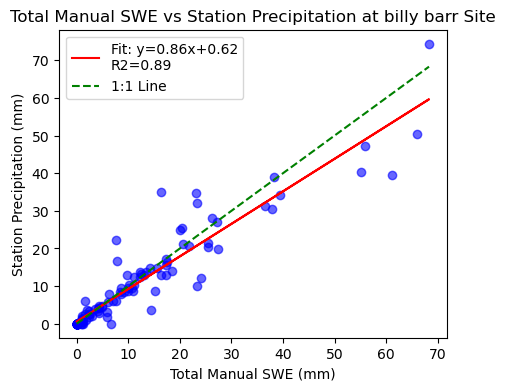

In [13]:
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(bb_comparison_snow_only_df['Manual_SWE_mm'], bb_comparison_snow_only_df['Station_Precipitation_mm'], color='blue', alpha=0.6)

slope, intercept, r_value, p_value, std_err = stats.linregress(bb_comparison_snow_only_df['Manual_SWE_mm'], bb_comparison_snow_only_df['Station_Precipitation_mm'])

ax.plot(bb_comparison_snow_only_df['Manual_SWE_mm'], intercept + slope*bb_comparison_snow_only_df['Manual_SWE_mm'], 'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}\nR2={r_value**2:.2f}')
ax.plot(bb_comparison_snow_only_df['Manual_SWE_mm'].sort_values(), bb_comparison_snow_only_df['Manual_SWE_mm'].sort_values(), 'g--', label='1:1 Line')
ax.legend()

ax.set_title('Total Manual SWE vs Station Precipitation at billy barr Site')
ax.set_xlabel('Total Manual SWE (mm)')
ax.set_ylabel('Station Precipitation (mm)')

Text(0, 0.5, 'Station Precipitation (mm)')

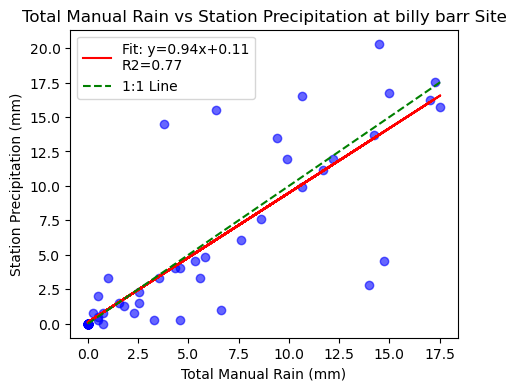

In [14]:
import scipy.stats as stats
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(bb_comparison_rain_only_df['Manual_Rain_mm'], bb_comparison_rain_only_df['Station_Precipitation_mm'], color='blue', alpha=0.6)

slope, intercept, r_value, p_value, std_err = stats.linregress(bb_comparison_rain_only_df['Manual_Rain_mm'], bb_comparison_rain_only_df['Station_Precipitation_mm'])

ax.plot(bb_comparison_rain_only_df['Manual_Rain_mm'], intercept + slope*bb_comparison_rain_only_df['Manual_Rain_mm'], 'r', label=f'Fit: y={slope:.2f}x+{intercept:.2f}\nR2={r_value**2:.2f}')
ax.plot(bb_comparison_rain_only_df['Manual_Rain_mm'].sort_values(), bb_comparison_rain_only_df['Manual_Rain_mm'].sort_values(), 'g--', label='1:1 Line')
ax.legend()
ax.set_title('Total Manual Rain vs Station Precipitation at billy barr Site')
ax.set_xlabel('Total Manual Rain (mm)')
ax.set_ylabel('Station Precipitation (mm)')

# Table-like figures

## Tables for comparison

In [102]:
def calc_bias(full_ds, benchmark, water_year, analysis_type, nan_threshold=0.8, gridded_vars=GRIDDED_VARS):
    # Select relevant time slice and clean dataset
    time_slice = get_relevant_dates(full_ds, analysis_type=analysis_type, water_year=water_year, gridded=False)
    ds = drop_bad_or_irrelevant_vars(full_ds.sel(time=time_slice), nan_threshold=nan_threshold)
    # calculate bias dataset
    var_to_mask = []
    bias_ds = (ds.sum() - ds[benchmark].sum())
    relative_accum = ds.sum() / ds[benchmark].sum()
    relative_bias = (2*bias_ds) / (ds.sum() + ds[benchmark].sum())

    for var in bias_ds.data_vars:
        if var in gridded_vars:
            continue
        var_ds = ds[[benchmark,var]].dropna(dim='time', how='any')

        if 'squire' in var:
            # adjust the bias to be relative to December 1 of the water year, if water year is None, set to 2022
            if (analysis_type == 'cold') and (water_year is not None):
                start_date = pd.Timestamp(f"{water_year-1}-12-01")
                end_date = pd.Timestamp(f"{water_year}-03-31")
                var_ds = ds[[benchmark,var]].where((ds['time'] >= start_date) & (ds['time'] <= end_date)).dropna(dim='time', how='any')
                bias_ds[var] = var_ds[var].sum() - var_ds[benchmark].sum()
                relative_accum[var] = var_ds[var].sum() / var_ds[benchmark].sum()
                relative_bias[var] = (2*bias_ds[var]) / (var_ds[var].sum() + var_ds[benchmark].sum())
            elif analysis_type == "all":
                wy22_start = pd.Timestamp("2021-12-01")
                wy22_end = pd.Timestamp("2022-03-31")
                wy23_start = pd.Timestamp("2022-12-01")
                wy23_end = pd.Timestamp("2023-03-31")
                var_ds_wy22 = ds[[benchmark,var]].where((ds['time'] >= wy22_start) & (ds['time'] <= wy22_end)).dropna(dim='time', how='any')
                var_ds_wy23 = ds[[benchmark,var]].where((ds['time'] >= wy23_start) & (ds['time'] <= wy23_end)).dropna(dim='time', how='any')
                bias_ds[var] = (var_ds_wy22[var].sum() - var_ds_wy22[benchmark].sum()) + (var_ds_wy23[var].sum() - var_ds_wy23[benchmark].sum())
                relative_accum[var] = (var_ds_wy22[var].sum() + var_ds_wy23[var].sum()) / (var_ds_wy22[benchmark].sum() + var_ds_wy23[benchmark].sum())
                relative_bias[var] = (2*bias_ds[var]) / ( (var_ds_wy22[var].sum() + var_ds_wy23[var].sum()) + (var_ds_wy22[benchmark].sum() + var_ds_wy23[benchmark].sum()) )
            else:
                var_to_mask.append(var)

        elif 'sos' in var:
            # adjust the bias to be relative to December 1 of the water year, if water year is None, set to 2022
            if (analysis_type == 'cold') and (water_year == 2023):
                start_date = pd.Timestamp(f"{water_year-1}-12-01")
                end_date = pd.Timestamp(f"{water_year}-03-31")
                var_ds = ds[[benchmark,var]].where((ds['time'] >= start_date) & (ds['time'] <= end_date)).dropna(dim='time', how='any')
                bias_ds[var] = var_ds[var].sum() - var_ds[benchmark].sum()
                relative_accum[var] = var_ds[var].sum() / var_ds[benchmark].sum()
                relative_bias[var] = (2*bias_ds[var]) / (var_ds[var].sum() + var_ds[benchmark].sum())
            elif analysis_type == "all" and water_year == 2023:
                start = pd.Timestamp("2022-12-01")
                end = pd.Timestamp("2023-03-31")
                var_ds = ds[[benchmark,var]].where((ds['time'] >= start) & (ds['time'] <= end)).dropna(dim='time', how='any')
                bias_ds[var] = var_ds[var].sum() - var_ds[benchmark].sum()
                relative_accum[var] = var_ds[var].sum() / var_ds[benchmark].sum()
                relative_bias[var] = (2*bias_ds[var]) / (var_ds[var].sum() + var_ds[benchmark].sum())
            else:
                var_to_mask.append(var)

        if var not in GRIDDED_VARS and analysis_type == 'warm' and water_year == 2023:
            var_to_mask.append(var)

    # add to series
    bias_series = np.round(bias_ds.sum().to_pandas(),1)
    relative_accum_series = np.round(relative_accum.to_pandas(),3)  
    relative_bias_series = np.round(relative_bias.to_pandas(),3)

    for var in var_to_mask:
        bias_series[var] = np.nan
        relative_accum_series[var] = np.nan
        relative_bias_series[var] = np.nan
    return bias_series, relative_accum_series, relative_bias_series

### Gothic

In [38]:
SITE = "gothic"
benchmark = "billy_barr_precip"

# Load dataset as dataframe
full_ds = get_dataset(SITE, DATA_DIR)
bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_warm','wy22_cold','wy23_warm','wy23_cold'], index=full_ds.drop_vars(benchmark).data_vars)
relative_accum_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_warm','wy22_cold','wy23_warm','wy23_cold'], index=full_ds.drop_vars(benchmark).data_vars)
relative_bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_warm','wy22_cold','wy23_warm','wy23_cold'], index=full_ds.drop_vars(benchmark).data_vars)

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "all"
ANALYSIS_TYPE = 'all'  # 'all', 'warm', 'cold'
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy22"
ANALYSIS_TYPE = 'all'  # 'all', 'warm', 'cold'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy23"
ANALYSIS_TYPE = 'all'  # 'all', 'warm', 'cold'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy22_warm"
ANALYSIS_TYPE = 'warm'  # 'all', 'warm', 'cold'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy22_cold"
ANALYSIS_TYPE = 'cold'  # 'all', 'warm', 'cold'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy23_warm"
ANALYSIS_TYPE = 'warm'  # 'all', 'warm', 'cold'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy23_cold"
ANALYSIS_TYPE = 'cold'  # 'all', 'warm', 'cold'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.9)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

# convert dataframes to numeric types
bias_df = bias_df.apply(pd.to_numeric, errors='coerce')
relative_accum_df = relative_accum_df.apply(pd.to_numeric, errors='coerce')
relative_bias_df = relative_bias_df.apply(pd.to_numeric, errors='coerce')

# update column names
updated_cols = dict(zip(bias_df.columns, ['Full Period', 'Water Year 2022', 'Water Year 2023', 'Warm Season 2022', 'Cold Season 2022', 'Warm Season 2023', 'Cold Season 2023']))
bias_df = bias_df.rename(columns=updated_cols).dropna(how='all')
relative_accum_df = relative_accum_df.rename(columns=updated_cols).dropna(how='all')
relative_bias_df = relative_bias_df.rename(columns=updated_cols).dropna(how='all')

In [40]:
# save as csv
bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_cumulative_precipitation_bias.csv")
relative_accum_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_relative_cumulative_precipitation.csv")
relative_bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_relative_precipitation_bias.csv")

#### Cumulative bias figure

In [41]:
# Keep NaNs to detect later
mask_nan = bias_df.isna()

# Replace NaNs with sentinel for plotting
bias_df_filled = bias_df.fillna(0)

# Create main heatmap (bias values)
fig = px.imshow(
    bias_df_filled,
    labels=dict(x="Analysis Period", y="Instrument or Product", color="Cumulative<br>Bias (mm)"),
    x=bias_df.columns,
    y=bias_df.index.str.replace("_", " ").str.title(),
    color_continuous_scale='RdBu',
    text_auto='.0f',
    aspect="auto",
    zmin=-300, zmax=300,
    title=f"Cumulative Precipitation Bias at {SITE.title()} Site (Benchmark = billy barr)"
)

# === Add gray fill + dark gray borders ===
nrows, ncols = bias_df.shape
for i, yi in enumerate(bias_df.index):
    for j, xj in enumerate(bias_df.columns):
        # Draw a dark gray border around each cell
        fig.add_shape(
            type="rect",
            x0=j - 0.5, x1=j + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color="darkgray", width=1),
            fillcolor="lightgray" if mask_nan.iloc[i, j] else "rgba(0,0,0,0)",
            layer="above"
        )

# Flip y-axis so first dataset is at top
fig.update_layout(
    yaxis_autorange="reversed",
    plot_bgcolor="white",
    width=1000,
    height=400 + 30 * nrows,  # adjust height based on number of rows
    font=dict(size=18)
)

# Optional: clearer hover
fig.update_traces(
    hovertemplate="%{x}<br>%{y}: %{z:.1f} mm<extra></extra>"
)


# save figure
output_filepath = OUTPUT_DIR / f"{SITE}_cumulative_precipitation_bias_heatmap.png"
fig.write_image(output_filepath, height=400 + 30 * nrows, width=1000, scale=1.5)

#### Relative accumulation figure

In [42]:
# Keep NaNs to detect later
mask_nan = relative_accum_df.isna()

# Replace NaNs with sentinel for plotting
relative_accum_df_filled = relative_accum_df.fillna(0)

# Create main heatmap (bias values)
fig = px.imshow(
    relative_accum_df_filled,
    labels=dict(x="Analysis Period", y="Instrument or Product", color="Relative Cumulative<br>Precipitation<br>(%)"),
    x=relative_accum_df.columns,
    y=relative_accum_df.index.str.replace("_", " ").str.title(),
    color_continuous_scale='RdBu',
    text_auto='.0f',
    aspect="auto",
    zmin=50, zmax=150,
    title=f"Relative Cumulative Precipitation at {SITE.title()} Site (Benchmark = billy barr)"
)

# === Add gray fill + dark gray borders ===
nrows, ncols = relative_accum_df.shape
for i, yi in enumerate(relative_accum_df.index):
    for j, xj in enumerate(relative_accum_df.columns):
        # Draw a dark gray border around each cell
        fig.add_shape(
            type="rect",
            x0=j - 0.5, x1=j + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color="darkgray", width=1),
            fillcolor="lightgray" if mask_nan.iloc[i, j] else "rgba(0,0,0,0)",
            layer="above"
        )

# Flip y-axis so first dataset is at top
fig.update_layout(
    yaxis_autorange="reversed",
    plot_bgcolor="white",
    width=1000,
    height=300 + 30 * nrows,  # adjust height based on number of rows
    font=dict(size=18)
)

# Optional: clearer hover
fig.update_traces(
    hovertemplate="%{x}<br>%{y}: %{z:.1f} %<extra></extra>",
)


# save figure
output_filepath = OUTPUT_DIR / f"{SITE}_relative_cumulative_precipitation_heatmap.png"
fig.write_image(output_filepath, height=400 + 30 * nrows, width=1000, scale=2)

#### Relative biase figure

In [43]:
# # Keep NaNs to detect later
# mask_nan = relative_bias_df.isna()

# # Replace NaNs with sentinel for plotting
# relative_bias_df_filled = relative_bias_df.fillna(0)

# Create main heatmap (bias values)
fig = px.imshow(
    relative_bias_df,
    labels=dict(x="Analysis Period", y="Instrument or Product", color="Fractional<br>Precipitation Bias<br>(%)"),
    x=relative_bias_df.columns,
    y=relative_bias_df.index.str.replace("_", " ").str.title(),
    color_continuous_scale='RdBu',
    text_auto='.0f',
    aspect="auto",
    zmin=-50, zmax=50,
    title=f"Fractional Precipitation Bias at {SITE.title()} Site (Benchmark = billy barr)"
)

# === Add gray fill + dark gray borders ===
nrows, ncols = relative_bias_df.shape
for i, yi in enumerate(relative_bias_df.index):
    for j, xj in enumerate(relative_bias_df.columns):
        # Draw a dark gray border around each cell
        fig.add_shape(
            type="rect",
            x0=j - 0.5, x1=j + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color="darkgray", width=1),
            fillcolor="lightgray" if mask_nan.iloc[i, j] else "rgba(0,0,0,0)",
            layer="above"
        )

# Flip y-axis so first dataset is at top
fig.update_layout(
    yaxis_autorange="reversed",
    plot_bgcolor="white",
    width=1000,
    height=400 + 30 * nrows,  # adjust height based on number of rows
    font=dict(size=18)
)

# Optional: clearer hover
fig.update_traces(
    hovertemplate="%{x}<br>%{y}: %{z:.1f} %<extra></extra>"
)


# save figure
output_filepath = OUTPUT_DIR / f"{SITE}_relative_precipitation_bias_heatmap.png"
fig.write_image(output_filepath, height=400 + 30 * nrows, width=1000, scale=2)

### Kettle Ponds

In [103]:
SITE = "kettle_ponds"
benchmark = "billy_barr_precip"

# Load dataset as dataframe
full_ds = get_dataset(SITE, DATA_DIR)
bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_warm','wy22_cold','wy23_warm','wy23_cold'], index=full_ds.drop_vars(benchmark).data_vars)
relative_accum_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_warm','wy22_cold','wy23_warm','wy23_cold'], index=full_ds.drop_vars(benchmark).data_vars)
relative_bias_df = pd.DataFrame(columns=['all','wy22','wy23','wy22_warm','wy22_cold','wy23_warm','wy23_cold'], index=full_ds.drop_vars(benchmark).data_vars)

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "all"
ANALYSIS_TYPE = 'all'  # 'all', 'warm', 'cold'
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy22"
ANALYSIS_TYPE = 'all'  # 'all', 'warm', 'cold'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy23"
ANALYSIS_TYPE = 'all'  # 'all', 'warm', 'cold'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy22_warm"
ANALYSIS_TYPE = 'warm'  # 'all', 'warm', 'cold'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy22_cold"
ANALYSIS_TYPE = 'cold'  # 'all', 'warm', 'cold'
WATER_YEAR = 2022  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy23_warm"
ANALYSIS_TYPE = 'warm'  # 'all', 'warm', 'cold'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

###### Calculate total precipitation bias and relative bias ######
COL_NAME = "wy23_cold"
ANALYSIS_TYPE = 'cold'  # 'all', 'warm', 'cold'
WATER_YEAR = 2023  # e.g., 2023 for Oct 2022 - Sep 2023; set to None for full data range
GRIDDED = False  #
bias, relative_accum, relative_bias = calc_bias(full_ds, benchmark, WATER_YEAR, ANALYSIS_TYPE, nan_threshold=0.7)
bias_df.loc[:, COL_NAME] = bias
relative_accum_df.loc[:, COL_NAME] = relative_accum*100
relative_bias_df.loc[:, COL_NAME] = relative_bias*100

# convert dataframes to numeric types
bias_df = bias_df.apply(pd.to_numeric, errors='coerce')
relative_accum_df = relative_accum_df.apply(pd.to_numeric, errors='coerce')
relative_bias_df = relative_bias_df.apply(pd.to_numeric, errors='coerce')

# update column names
updated_cols = dict(zip(bias_df.columns, ['Full Period', 'Water Year 2022', 'Water Year 2023', 'Warm Season 2022', 'Cold Season 2022', 'Warm Season 2023', 'Cold Season 2023']))
bias_df = bias_df.rename(columns=updated_cols).dropna(how='all')
relative_accum_df = relative_accum_df.rename(columns=updated_cols).dropna(how='all')
relative_bias_df = relative_bias_df.rename(columns=updated_cols).dropna(how='all')

In [104]:
# save as csv
bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_cumulative_precipitation_bias.csv")
relative_accum_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_relative_cumulative_precipitation.csv")
relative_bias_df.to_csv(TABLE_OUTPUT_DIR / f"{SITE}_relative_precipitation_bias.csv")

#### Cumulative bias figure

In [105]:
# Keep NaNs to detect later
mask_nan = bias_df.isna()

# Replace NaNs with sentinel for plotting
bias_df_filled = bias_df.fillna(0)

# Create main heatmap (bias values)
fig = px.imshow(
    bias_df_filled,
    labels=dict(x="Analysis Period", y="Instrument or Product", color="Cumulative<br>Bias (mm)"),
    x=bias_df.columns,
    y=bias_df.index.str.replace("_", " ").str.title(),
    color_continuous_scale='RdBu',
    text_auto='.0f',
    aspect="auto",
    zmin=-300, zmax=300,
    title=f"Cumulative Precipitation Bias at {SITE.replace("_", " ").title()} Site (Benchmark = billy barr)"
)

# === Add gray fill + dark gray borders ===
nrows, ncols = bias_df.shape
for i, yi in enumerate(bias_df.index):
    for j, xj in enumerate(bias_df.columns):
        # Draw a dark gray border around each cell
        fig.add_shape(
            type="rect",
            x0=j - 0.5, x1=j + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color="darkgray", width=1),
            fillcolor="lightgray" if mask_nan.iloc[i, j] else "rgba(0,0,0,0)",
            layer="above"
        )

# Flip y-axis so first dataset is at top
fig.update_layout(
    yaxis_autorange="reversed",
    plot_bgcolor="white",
    width=1000,
    height=400 + 30 * nrows,  # adjust height based on number of rows
    font=dict(size=18)
)

# Optional: clearer hover
fig.update_traces(
    hovertemplate="%{x}<br>%{y}: %{z:.1f} mm<extra></extra>"
)

# save figure
output_filepath = OUTPUT_DIR / f"{SITE}_cumulative_precipitation_bias_heatmap.png"
fig.write_image(output_filepath, height=400 + 30 * nrows, width=1000, scale=1.5)

#### Relative accumulation figure

In [106]:
# Keep NaNs to detect later
mask_nan = relative_accum_df.isna()

# Replace NaNs with sentinel for plotting
relative_accum_df_filled = relative_accum_df.fillna(0)

# Create main heatmap (bias values)
fig = px.imshow(
    relative_accum_df_filled,
    labels=dict(x="Analysis Period", y="Instrument or Product", color="Relative Cumulative<br>Precipitation<br>(%)"),
    x=relative_accum_df.columns,
    y=relative_accum_df.index.str.replace("_", " ").str.title(),
    color_continuous_scale='RdBu',
    text_auto='.0f',
    aspect="auto",
    zmin=50, zmax=150,
    title=f"Relative Cumulative Precipitation at {SITE.replace('_', ' ').title()} Site (Benchmark = billy barr)"
)

# === Add gray fill + dark gray borders ===
nrows, ncols = relative_accum_df.shape
for i, yi in enumerate(relative_accum_df.index):
    for j, xj in enumerate(relative_accum_df.columns):
        # Draw a dark gray border around each cell
        fig.add_shape(
            type="rect",
            x0=j - 0.5, x1=j + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color="darkgray", width=1),
            fillcolor="lightgray" if mask_nan.iloc[i, j] else "rgba(0,0,0,0)",
            layer="above"
        )

# Flip y-axis so first dataset is at top
fig.update_layout(
    yaxis_autorange="reversed",
    plot_bgcolor="white",
    width=1000,
    height=300 + 30 * nrows,  # adjust height based on number of rows
    font=dict(size=18)
)

# Optional: clearer hover
fig.update_traces(
    hovertemplate="%{x}<br>%{y}: %{z:.1f} %<extra></extra>",
)


# save figure
output_filepath = OUTPUT_DIR / f"{SITE}_relative_cumulative_precipitation_heatmap.png"
fig.write_image(output_filepath, height=400 + 30 * nrows, width=1000, scale=2)

#### Relative biase figure

In [107]:
# Keep NaNs to detect later
mask_nan = relative_bias_df.isna()

# Replace NaNs with sentinel for plotting
relative_bias_df_filled = relative_bias_df.fillna(0)

# Create main heatmap (bias values)
fig = px.imshow(
    relative_bias_df_filled,
    labels=dict(x="Analysis Period", y="Instrument or Product", color="Fractional<br>Precipitation Bias<br>(%)"),
    x=relative_bias_df.columns,
    y=relative_bias_df.index.str.replace("_", " ").str.title(),
    color_continuous_scale='RdBu',
    text_auto='.0f',
    aspect="auto",
    zmin=-50, zmax=50,
    title=f"Fractional Precipitation Bias at {SITE.replace('_', ' ').title()} Site (Benchmark = billy barr)"
)

# === Add gray fill + dark gray borders ===
nrows, ncols = relative_bias_df.shape
for i, yi in enumerate(relative_bias_df.index):
    for j, xj in enumerate(relative_bias_df.columns):
        # Draw a dark gray border around each cell
        fig.add_shape(
            type="rect",
            x0=j - 0.5, x1=j + 0.5,
            y0=i - 0.5, y1=i + 0.5,
            line=dict(color="darkgray", width=1),
            fillcolor="lightgray" if mask_nan.iloc[i, j] else "rgba(0,0,0,0)",
            layer="above"
        )

# Flip y-axis so first dataset is at top
fig.update_layout(
    yaxis_autorange="reversed",
    plot_bgcolor="white",
    width=1000,
    height=400 + 30 * nrows,  # adjust height based on number of rows
    font=dict(size=18)
)

# Optional: clearer hover
fig.update_traces(
    hovertemplate="%{x}<br>%{y}: %{z:.1f} %<extra></extra>"
)


# save figure
output_filepath = OUTPUT_DIR / f"{SITE}_relative_precipitation_bias_heatmap.png"
fig.write_image(output_filepath, height=400 + 30 * nrows, width=1000, scale=2)

# Accumulation Figures

## Total precipitation comparison - Figures

In [108]:
ANALYSIS_TYPE = 'all'  # options: 'all', 'warm', 'cold'

### Gothic

In [128]:
SITE = "gothic"
WATER_YEAR = None  # e.g., 2023 for Oct 2022 - Sep 2023; set to None if not seasonal analysis
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[GRIDDED_VARS], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[GRIDDED_VARS].sel(time=gridded_time_slice).resample(time='1D').sum())

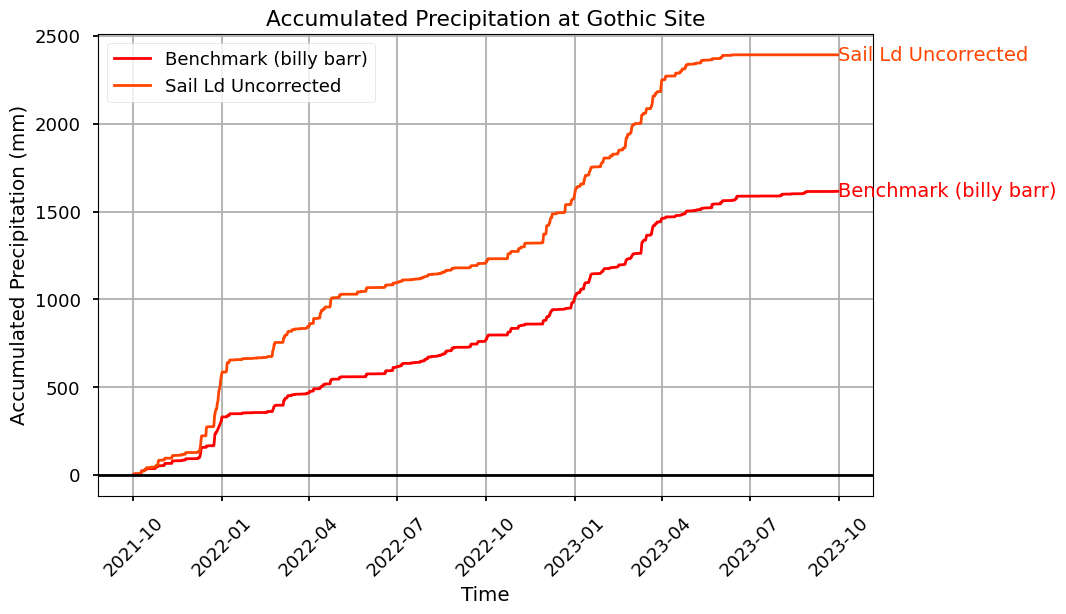

In [110]:
# example figure
fig = plot_accumulated_precipitation(
    ds=ds[['billy_barr_precip','sail_ld_uncorrected']],
    site=SITE,
    water_year=WATER_YEAR,
    analysis_type=ANALYSIS_TYPE,
    plot_lib='plt',
    legend=True
)

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_all_data_prcp_taylor.png


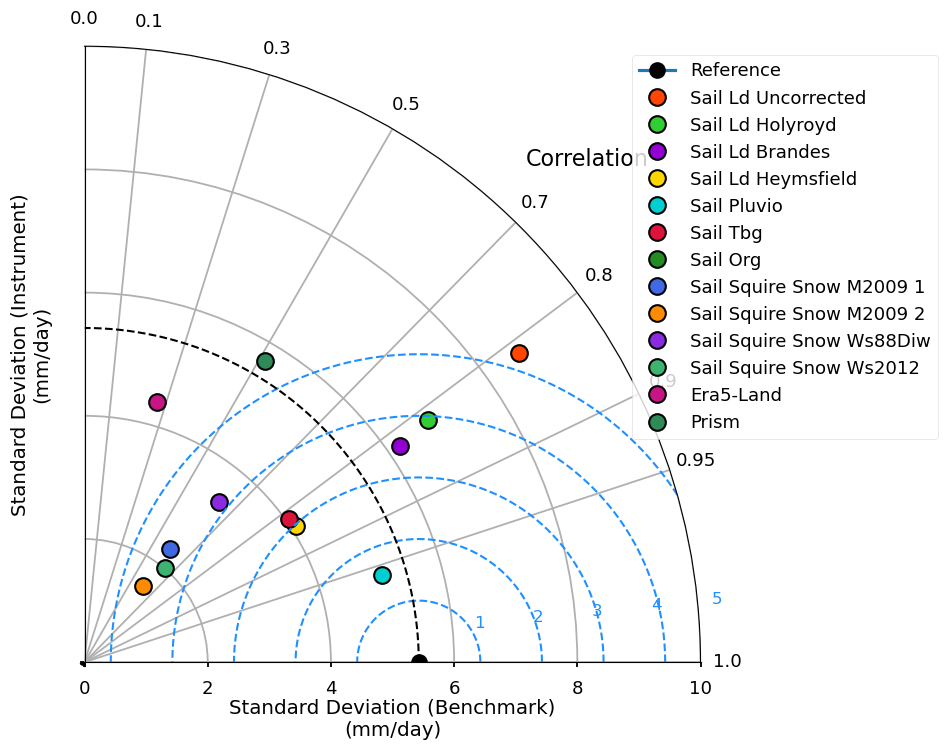

In [143]:
fig = plot_taylor_diagram(ds, benchmark='billy_barr_precip')

save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='taylor', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_all_data_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_all_data_prcp_bias.png


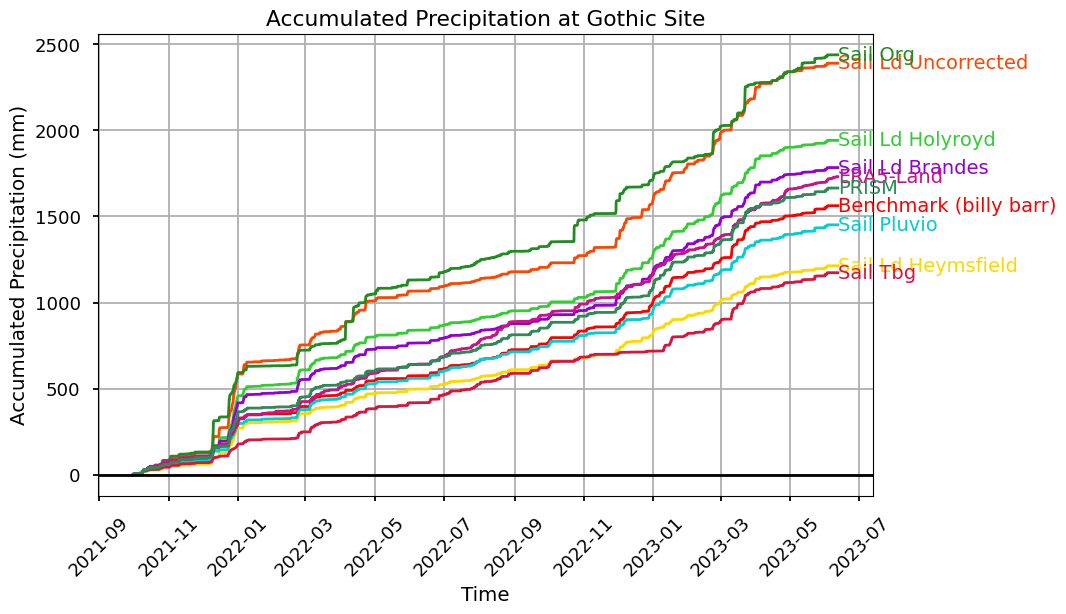

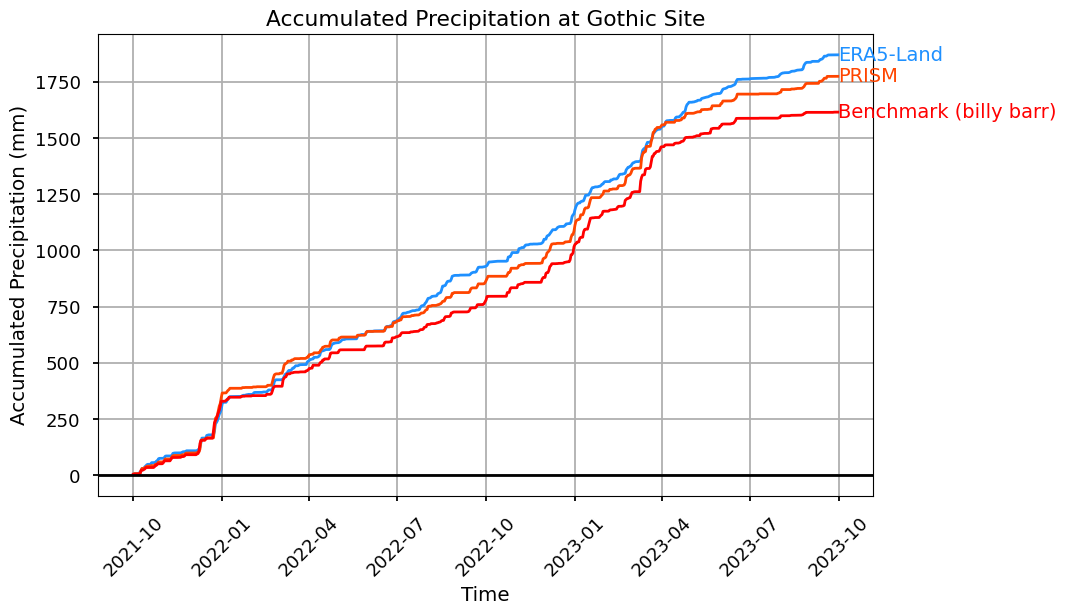

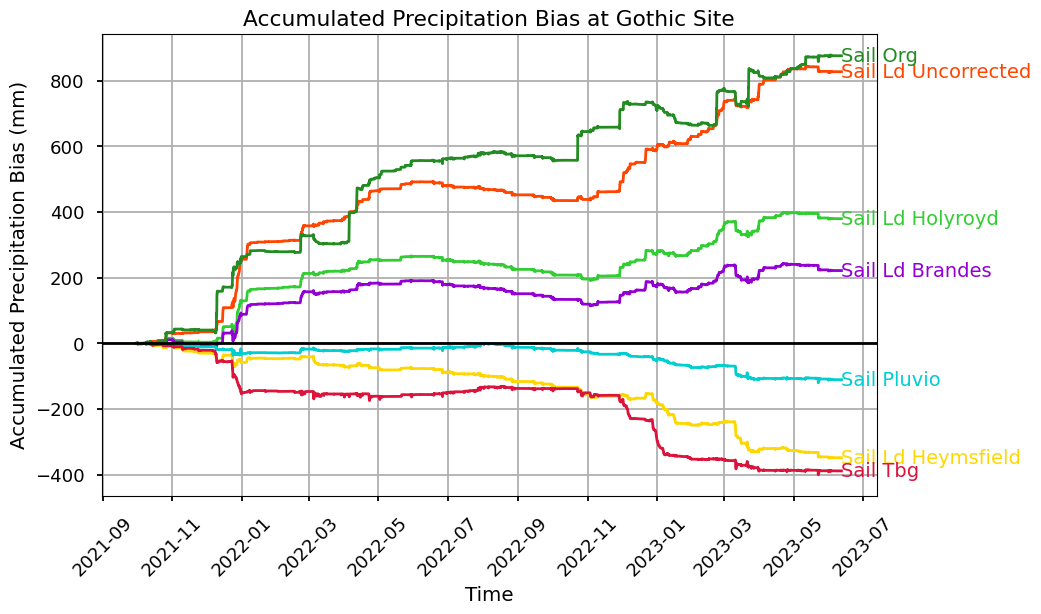

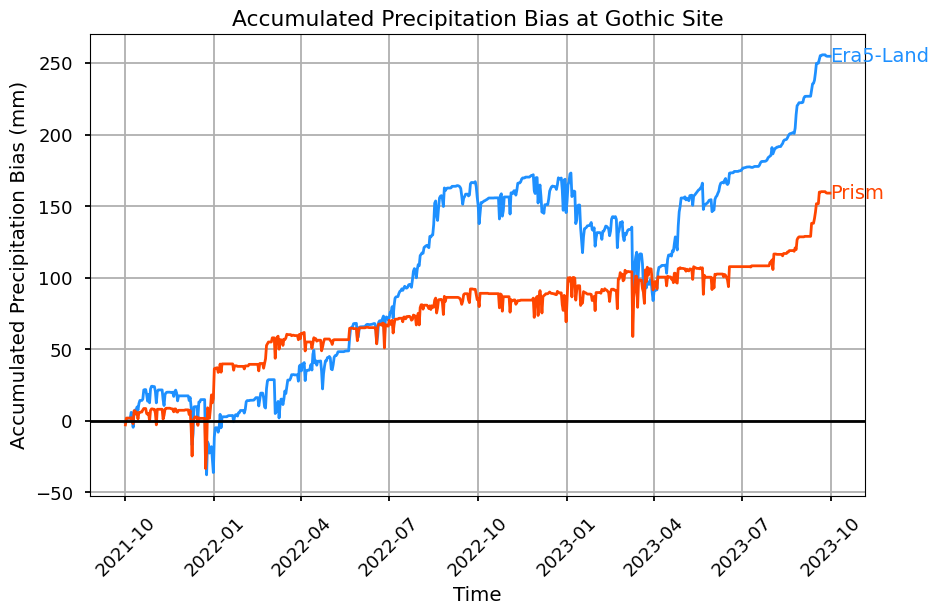

In [149]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [31]:
SITE = "kettle_ponds"

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

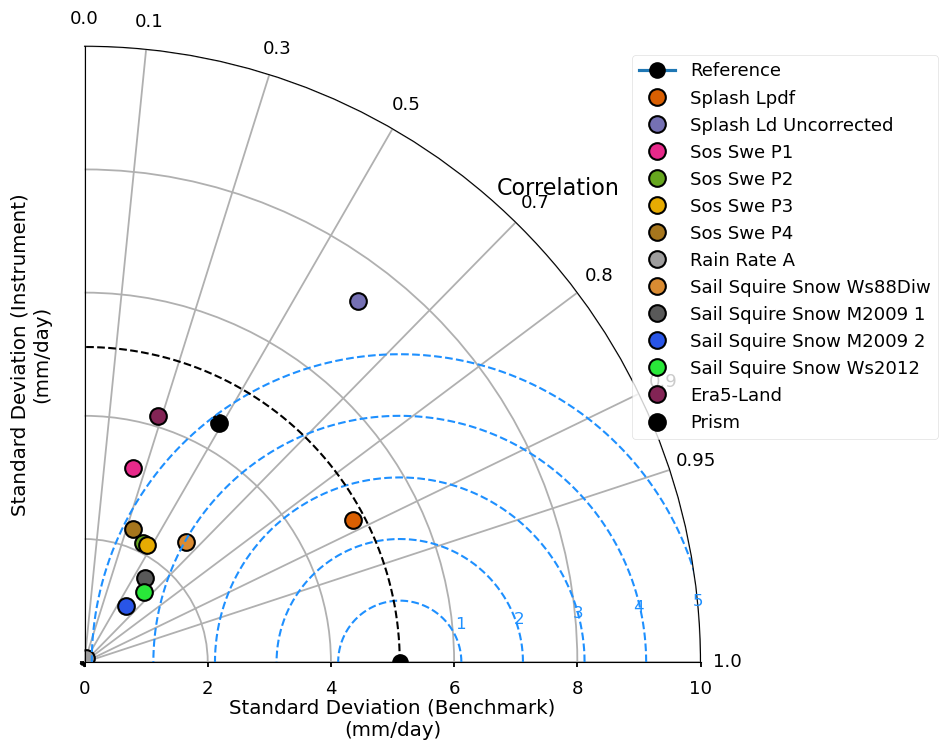

In [32]:
plot_taylor_diagram(ds, benchmark='billy_barr_precip')

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_bias.png


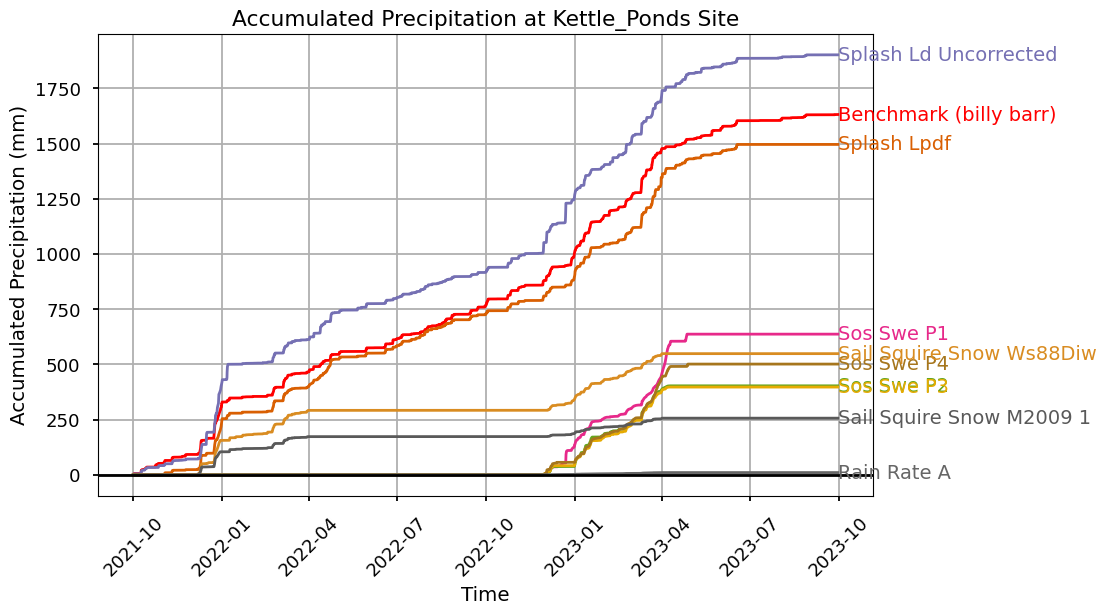

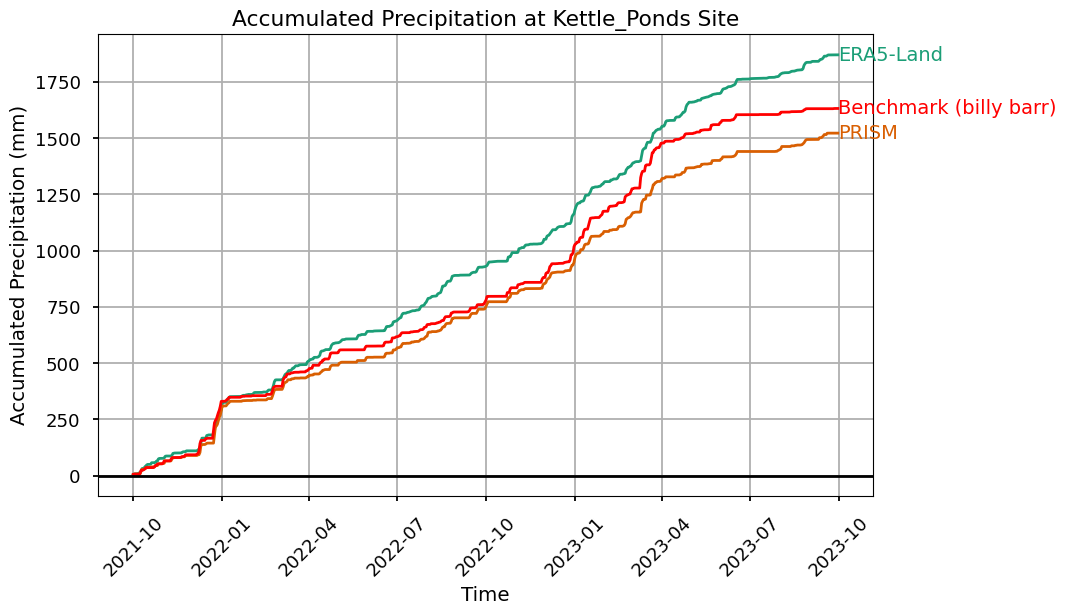

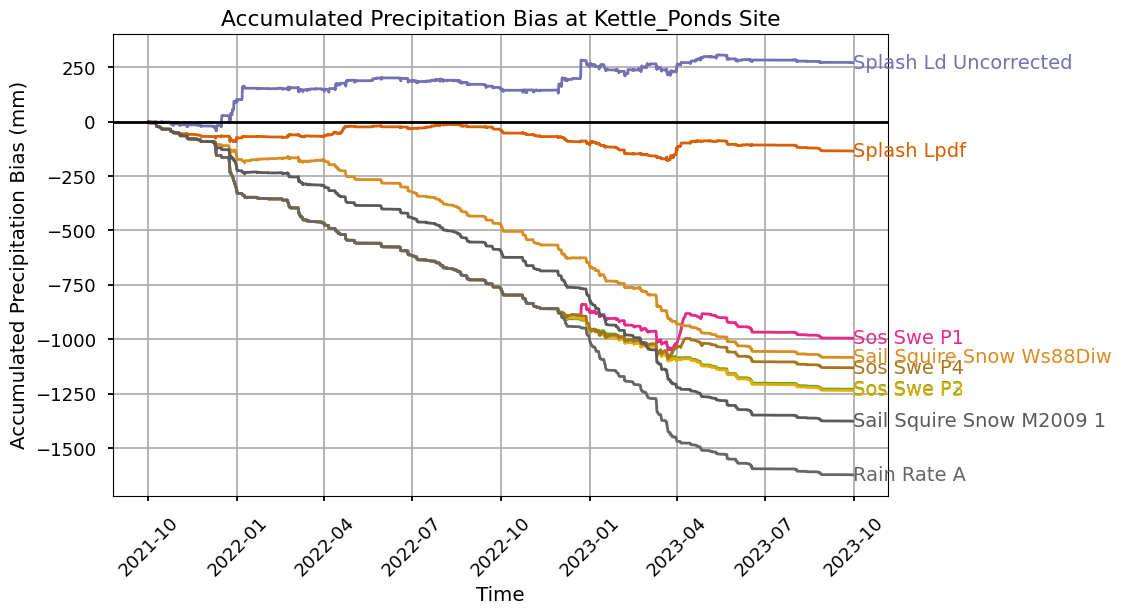

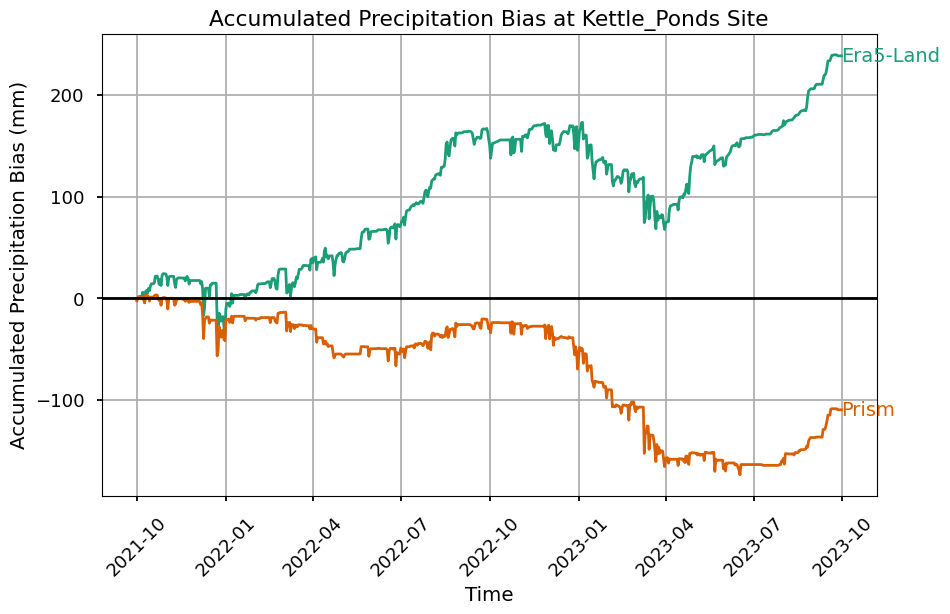

In [33]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

## Water year total precipitation comparison

### Gothic

In [34]:
SITE = "gothic"

#### Water Year 2022

In [35]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_2022_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_2022_prcp_bias.png


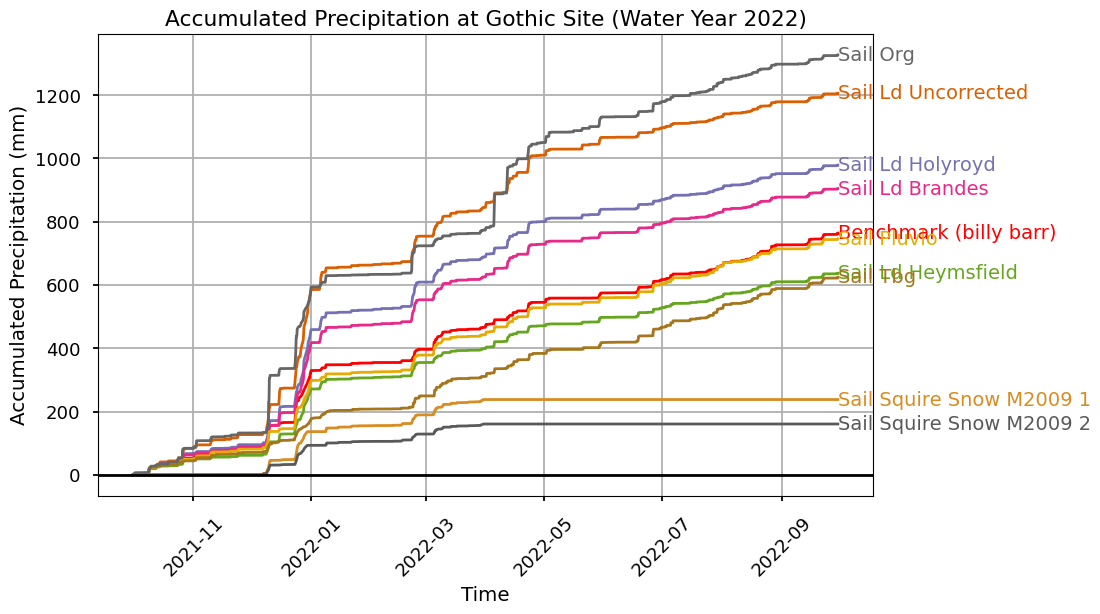

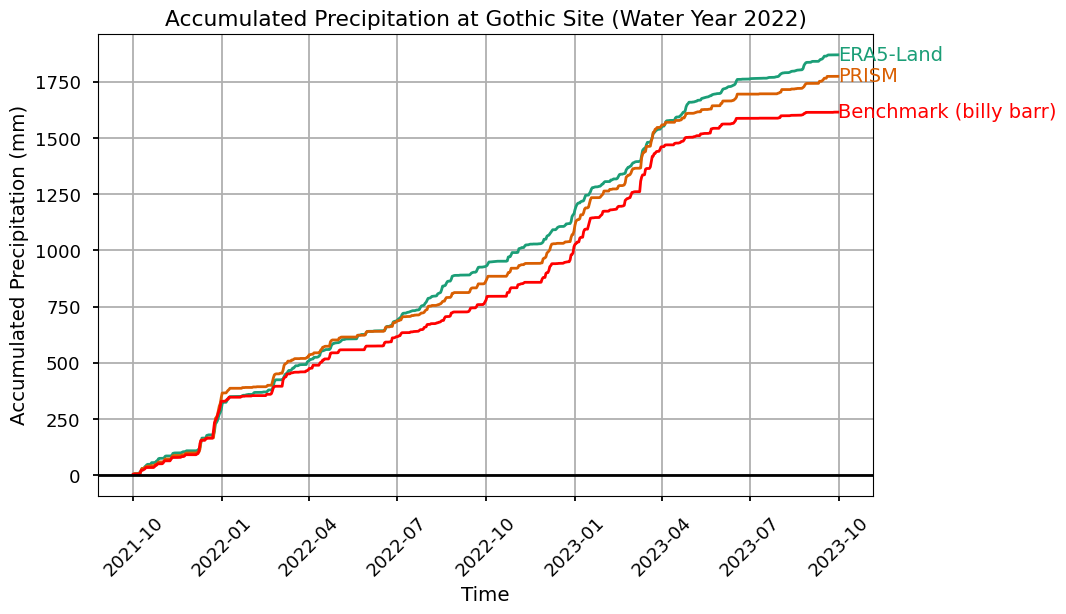

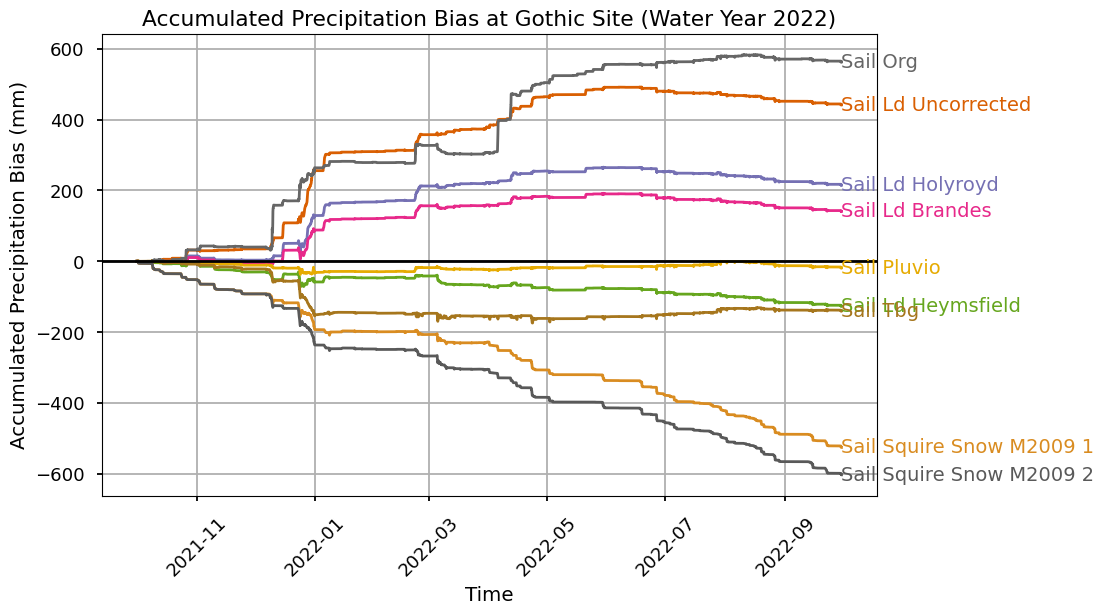

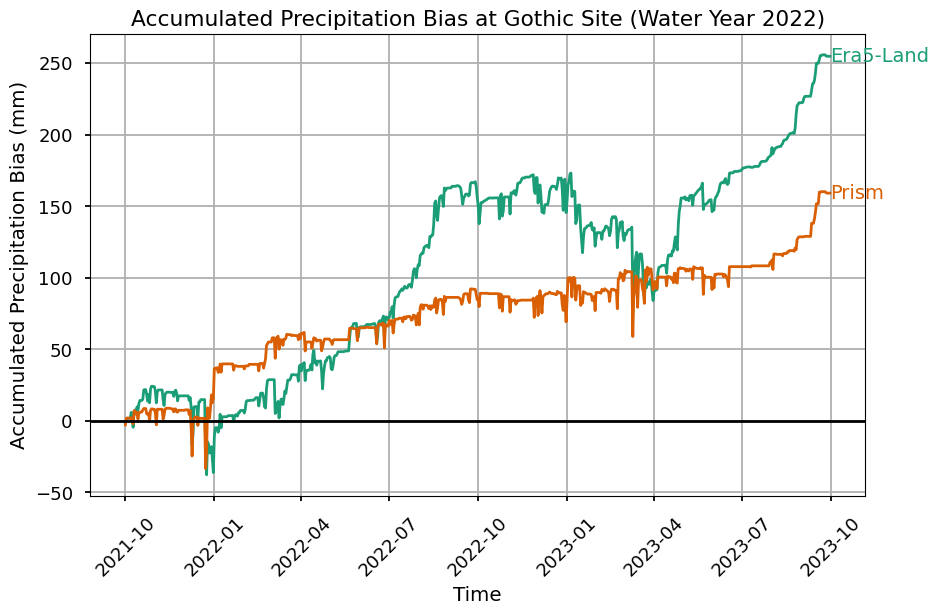

In [36]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

#### Water Year 2023

In [150]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_2023_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_2023_prcp_bias.png


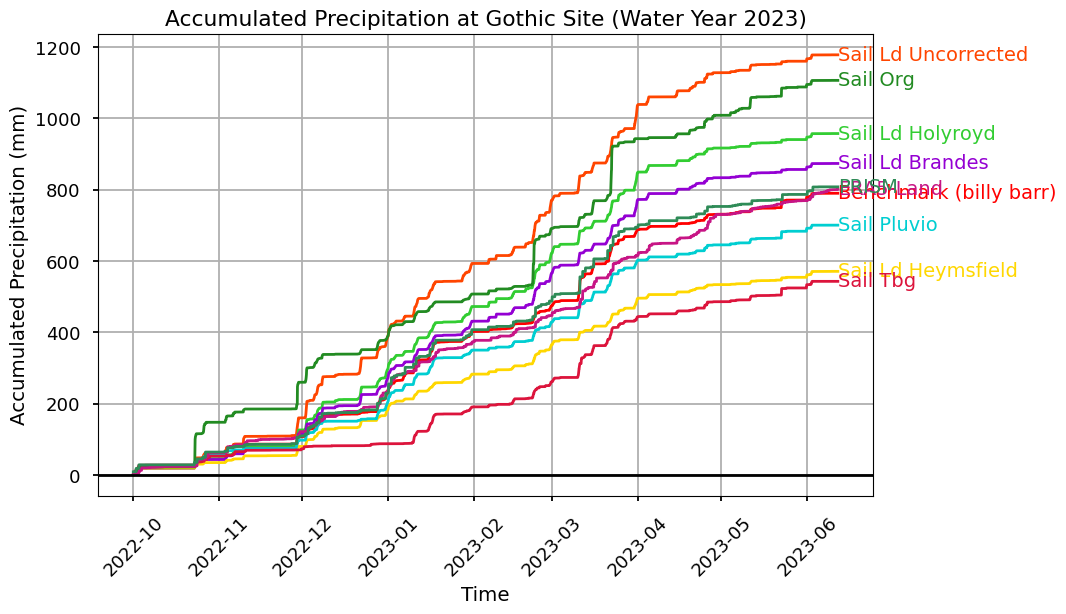

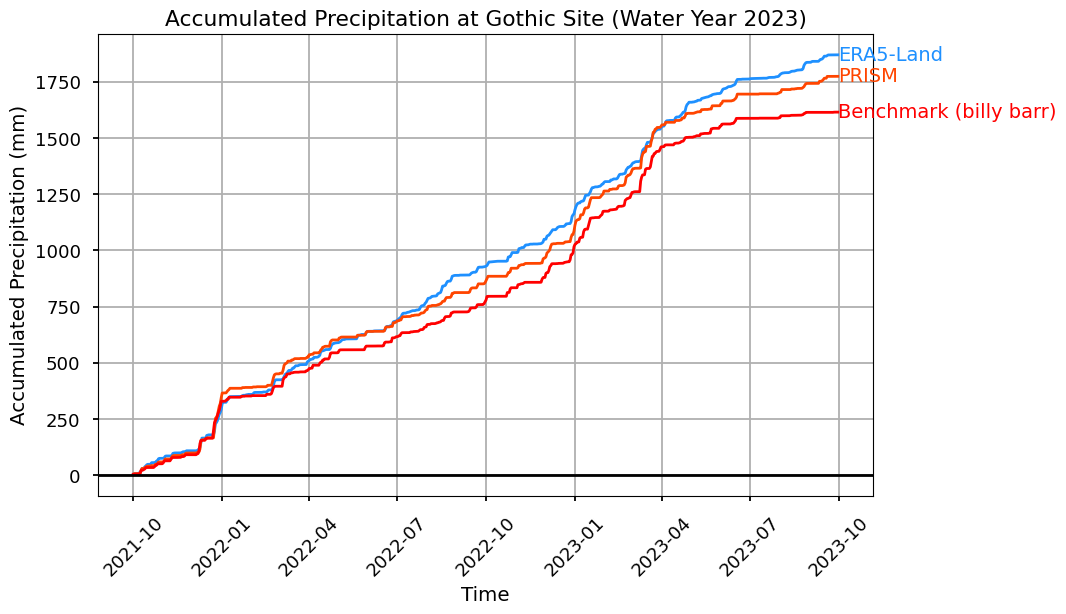

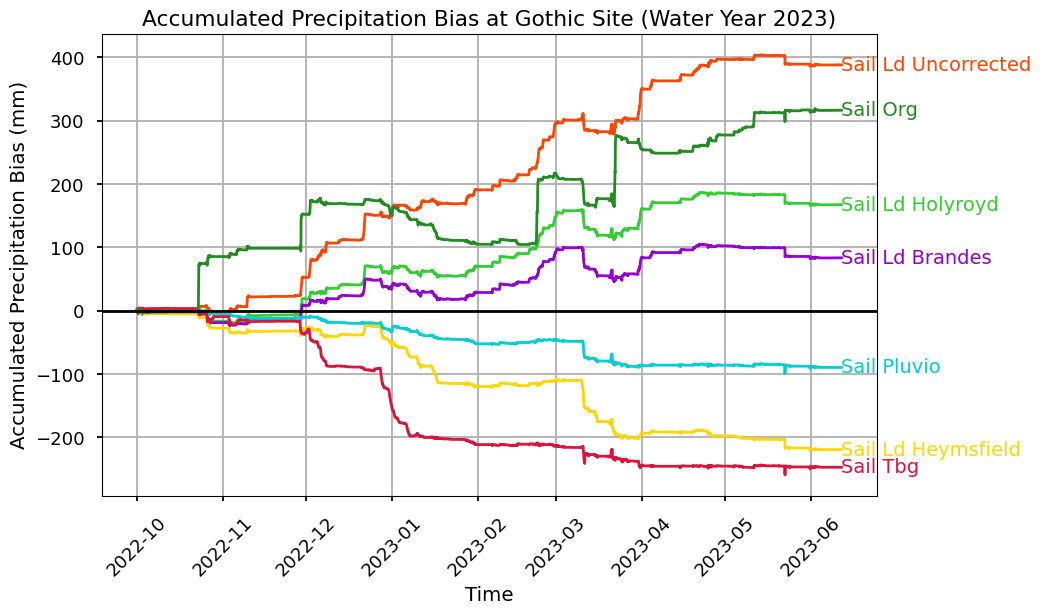

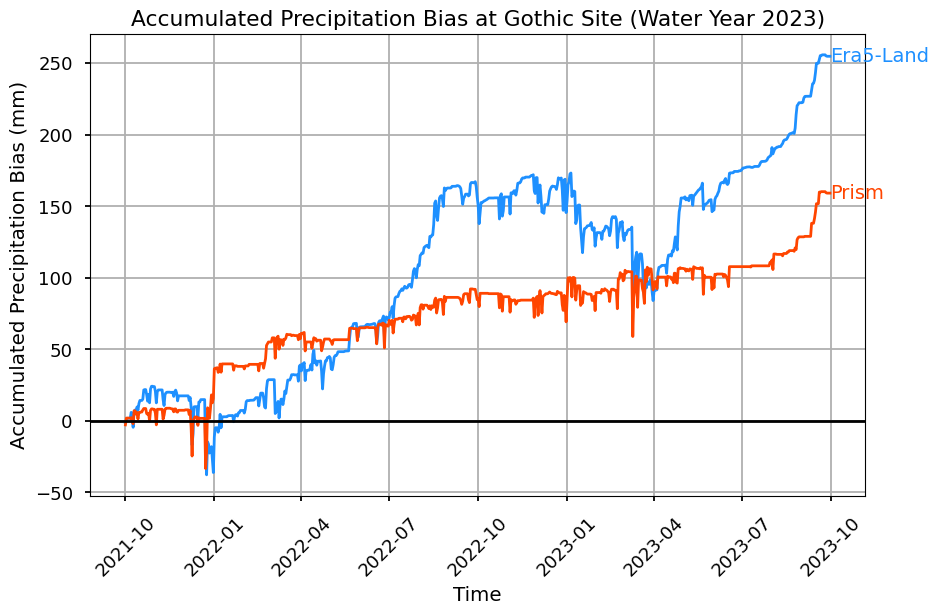

In [151]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [152]:
SITE = "kettle_ponds"

#### Water Year 2022

In [153]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))

ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_2022_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_2022_prcp_bias.png


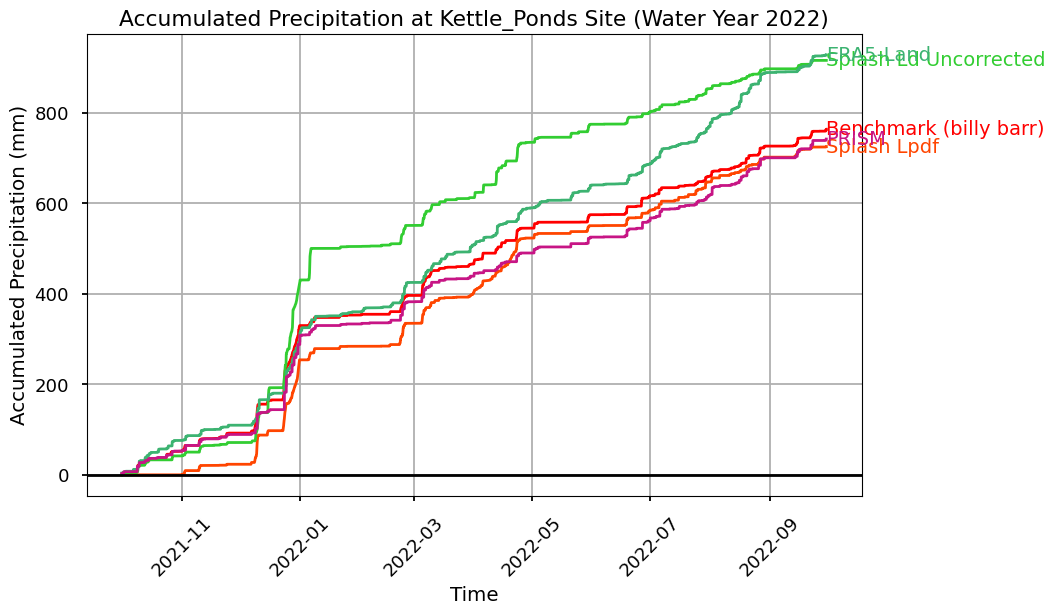

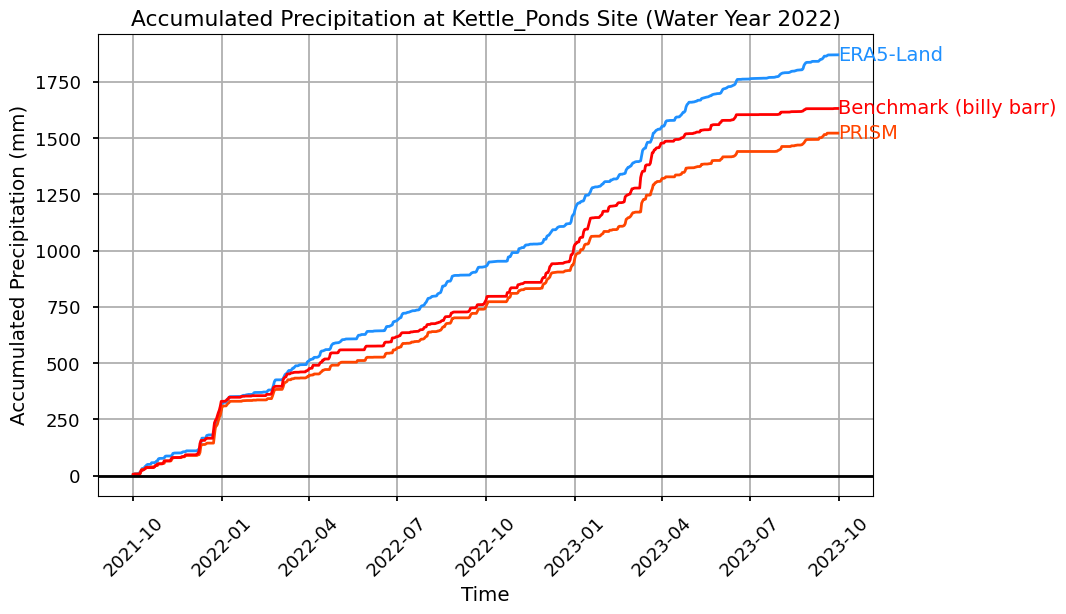

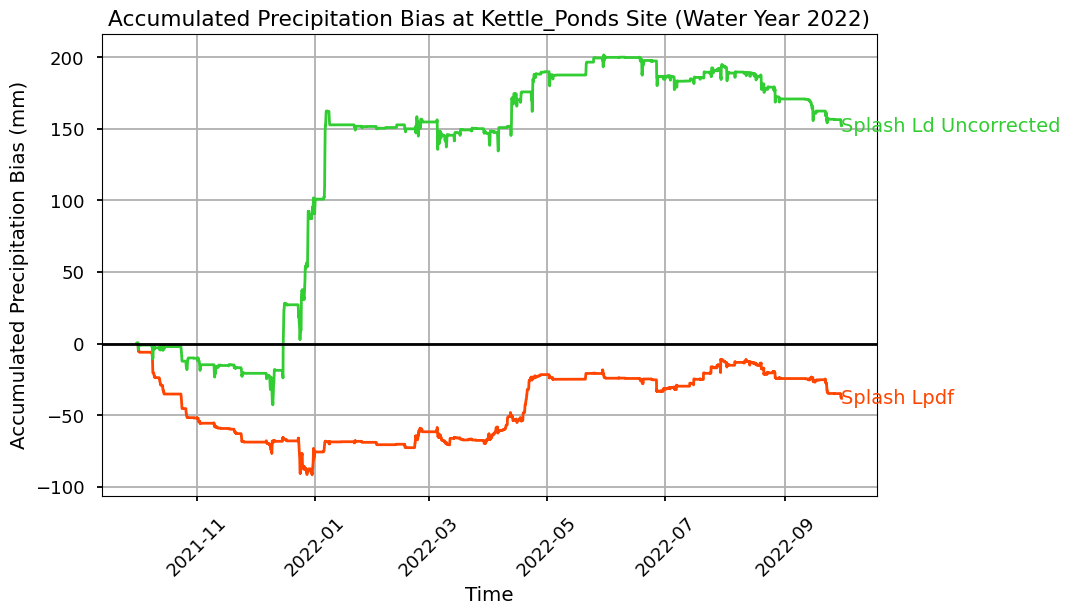

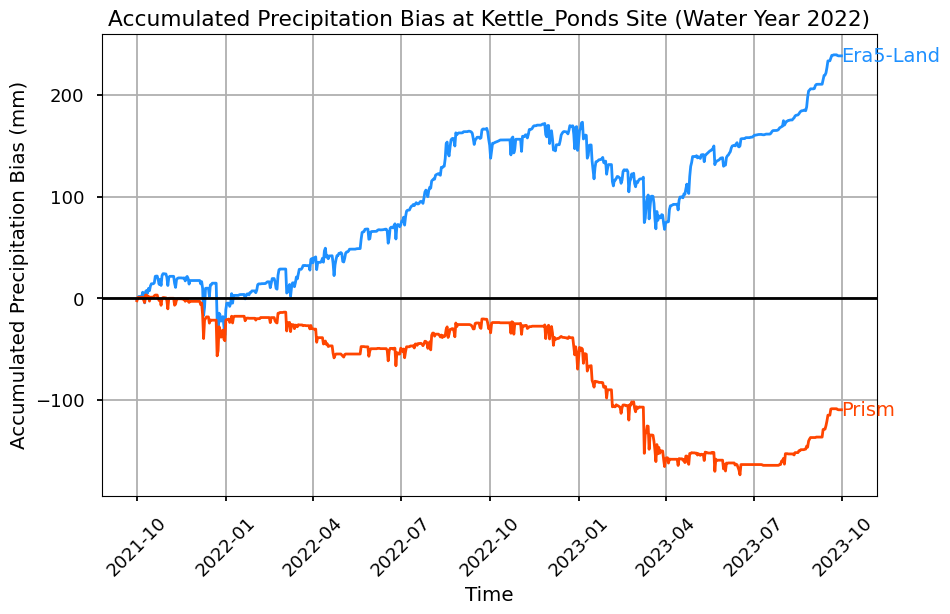

In [160]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

#### Water Year 2023

In [161]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_2023_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_2023_prcp_bias.png


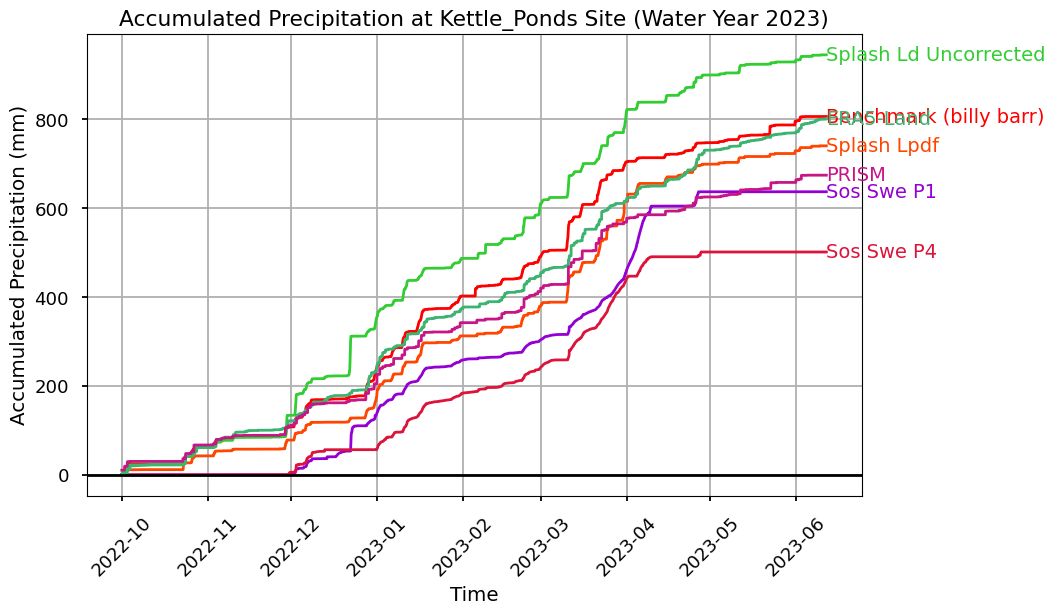

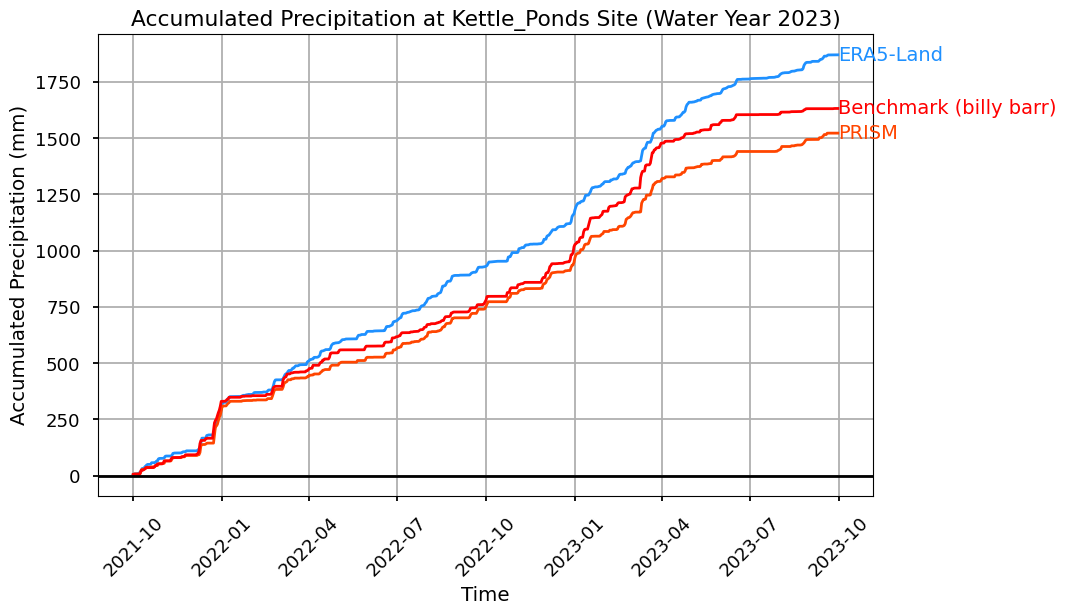

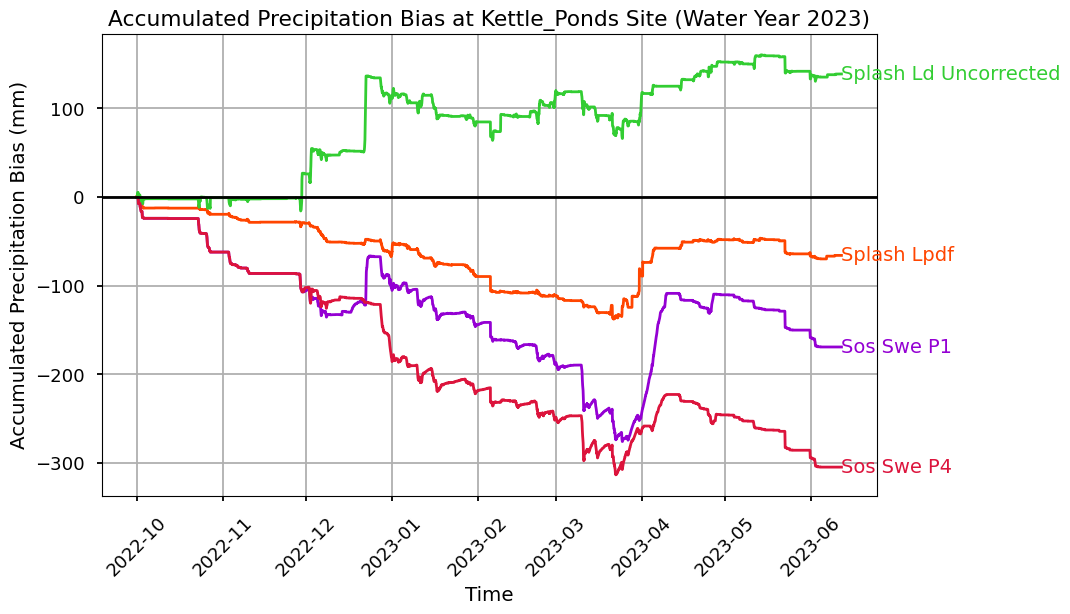

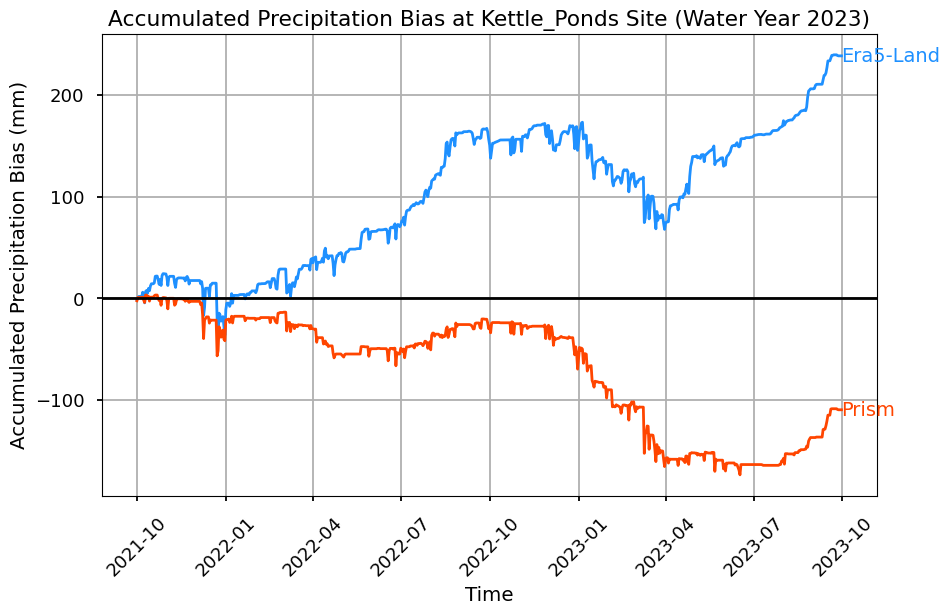

In [163]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR,)

## Seasonal total precipitation comparison by water year

### Gothic

In [164]:
SITE = 'gothic'

#### Cold Season (November - April)

In [170]:
ANALYSIS_TYPE = 'cold'  # options: 'all', 'warm', 'cold'

##### Water Year 2022

In [171]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_cold_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_cold_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_cold_season_2022_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_cold_season_2022_prcp_bias.png


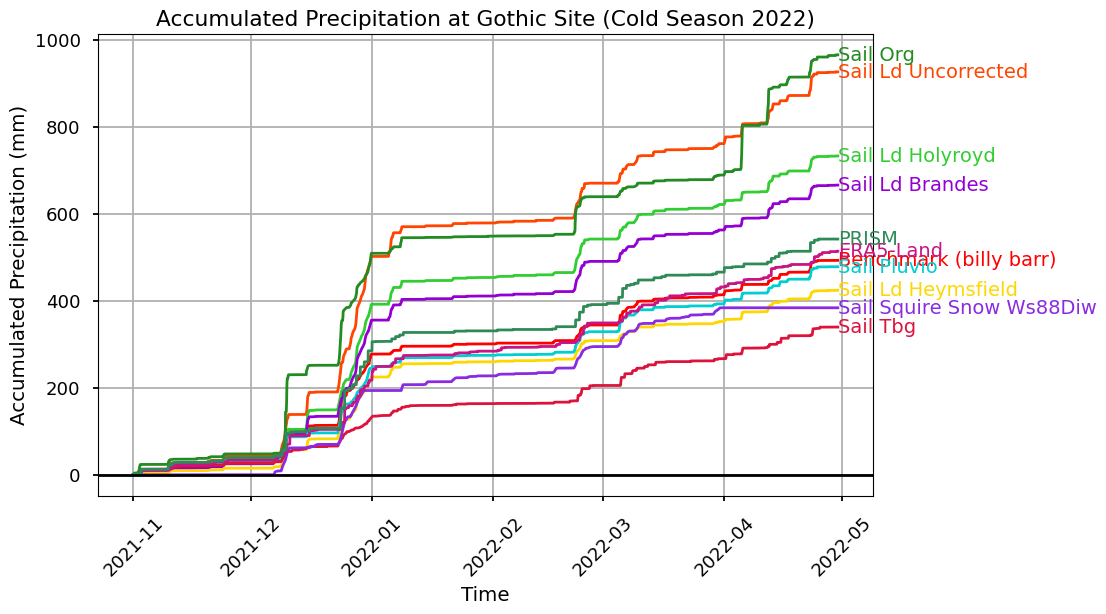

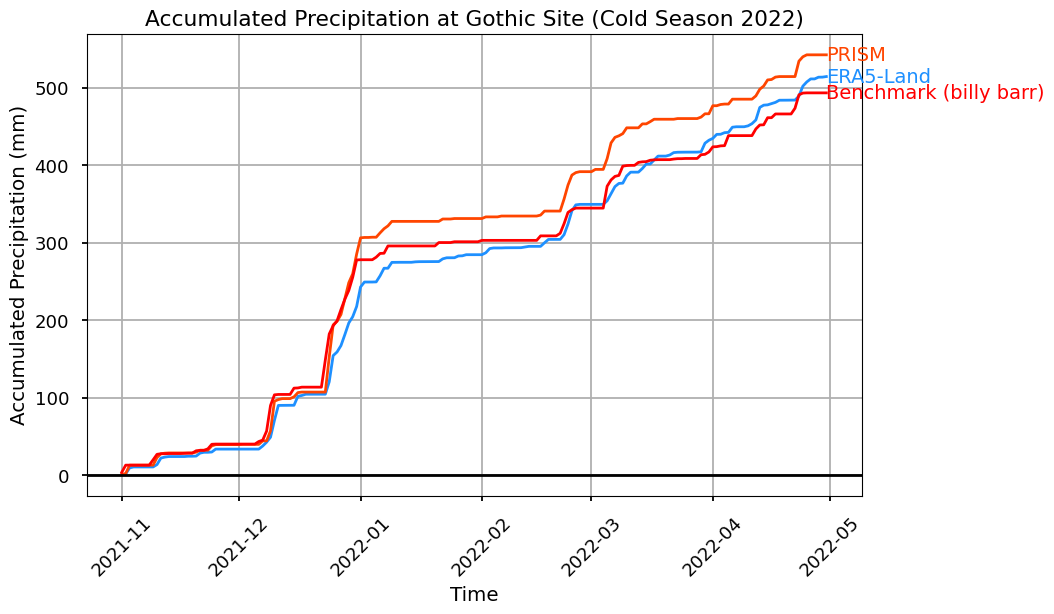

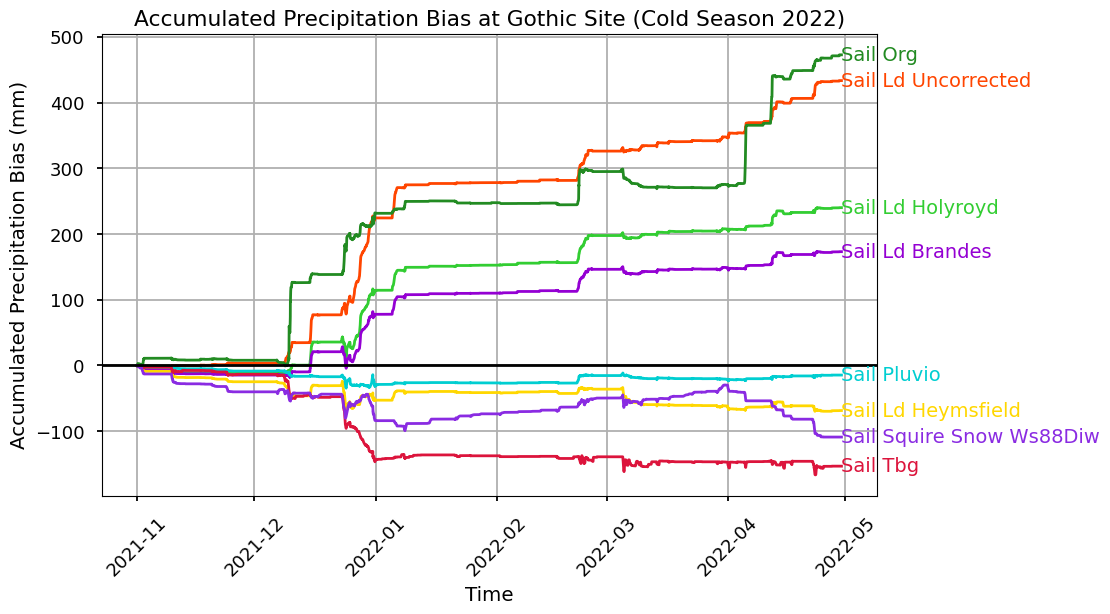

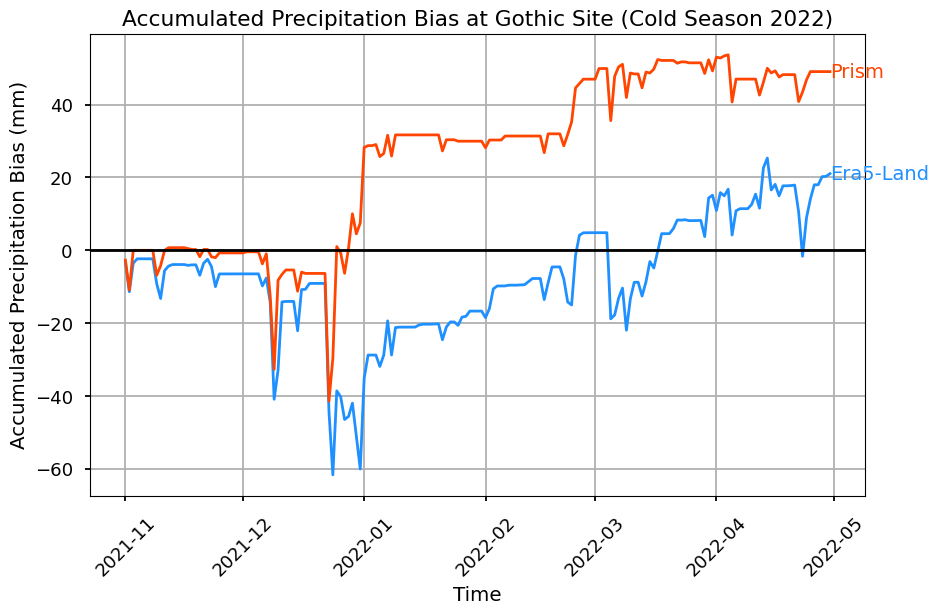

In [172]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [173]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_cold_season_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_cold_season_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_cold_season_2023_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_cold_season_2023_prcp_bias.png


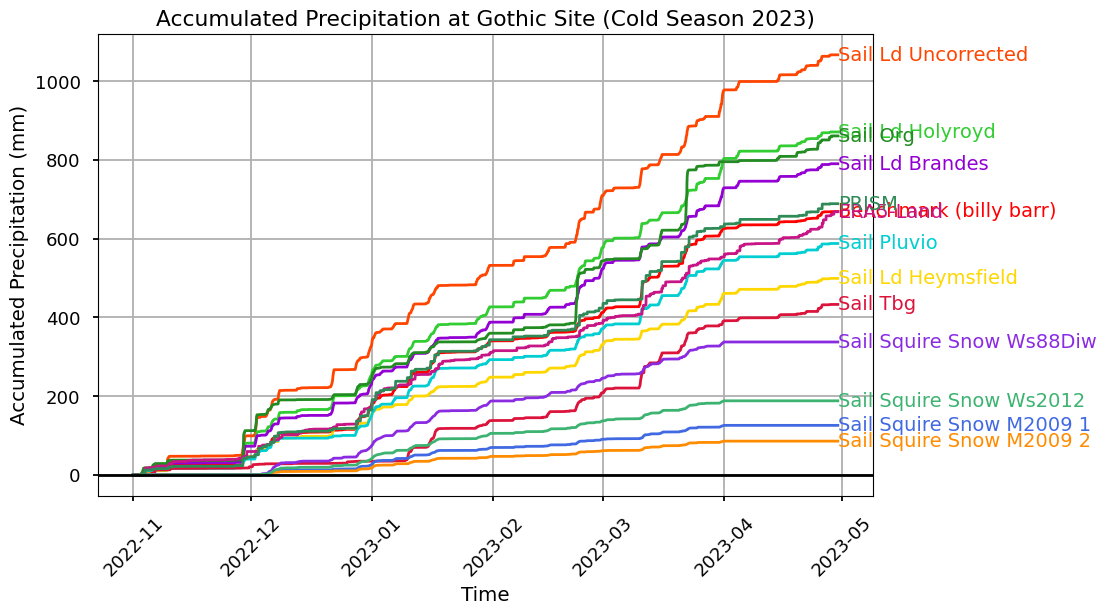

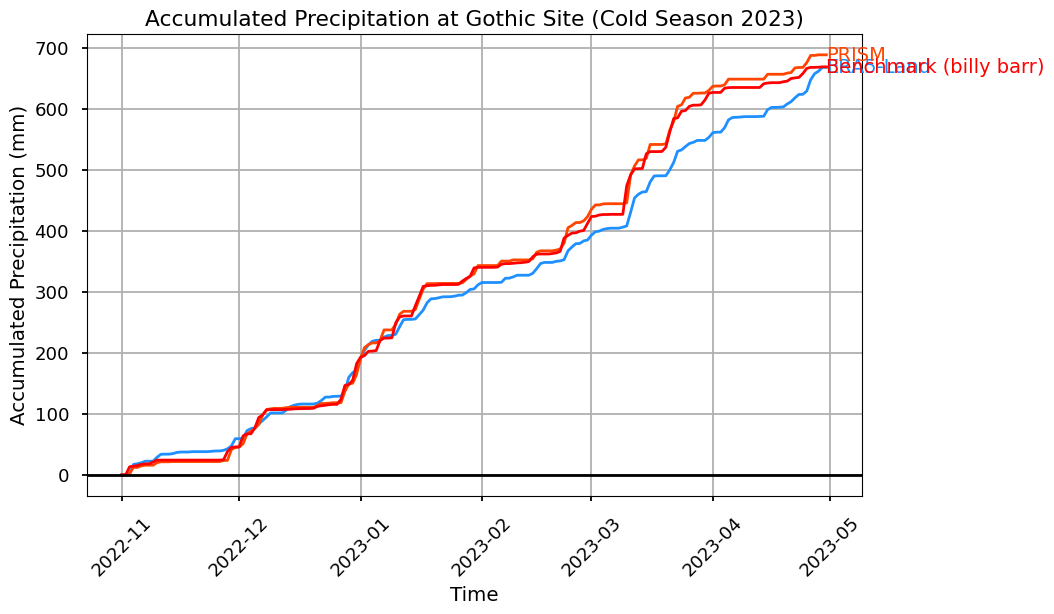

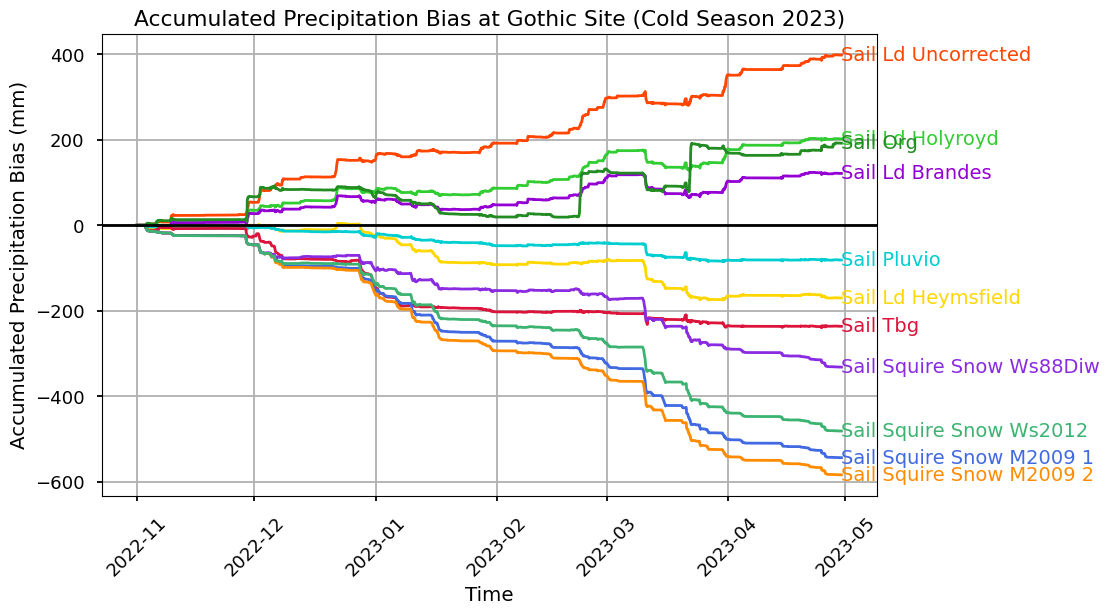

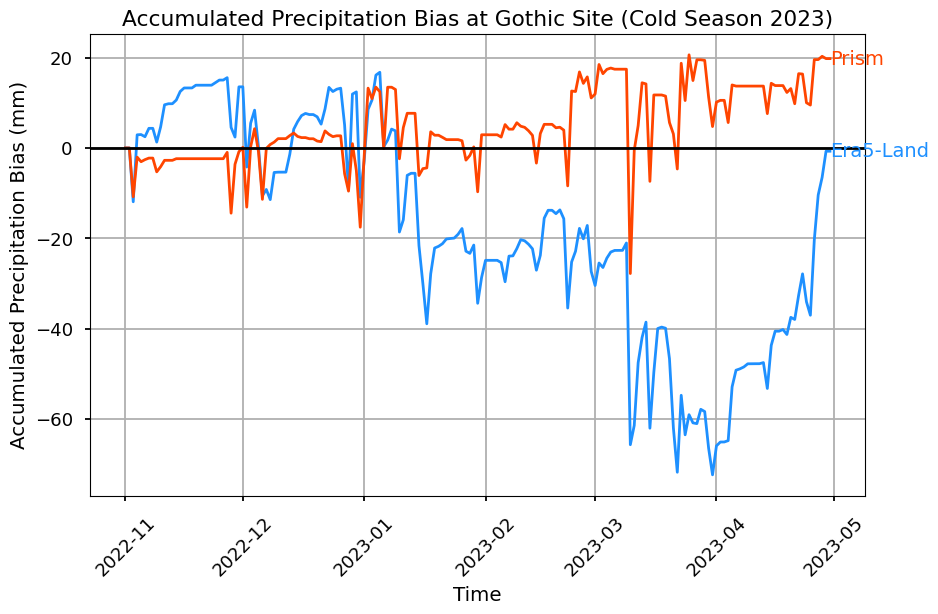

In [174]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

#### Warm Season (May - October)

In [175]:
ANALYSIS_TYPE = 'warm'  # options: 'all', 'warm', 'cold'

##### Water Year 2022

In [176]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_warm_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_warm_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_warm_season_2022_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_warm_season_2022_prcp_bias.png


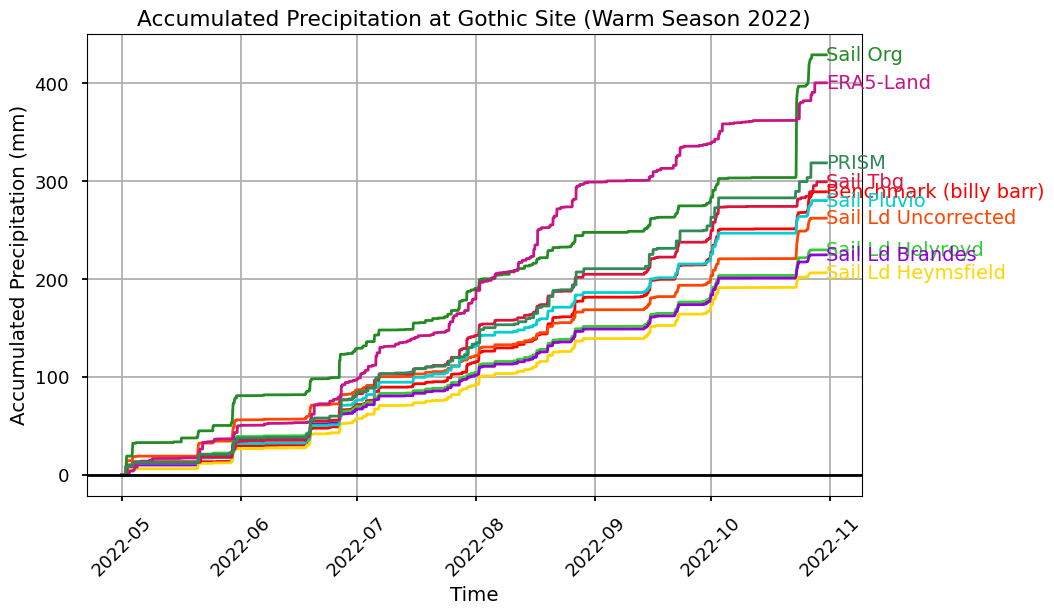

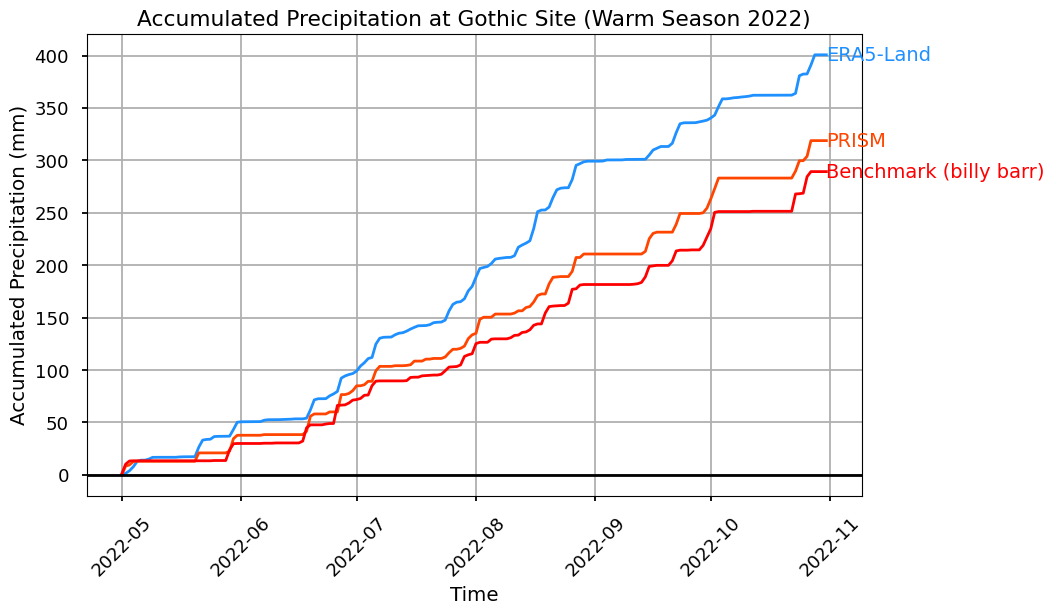

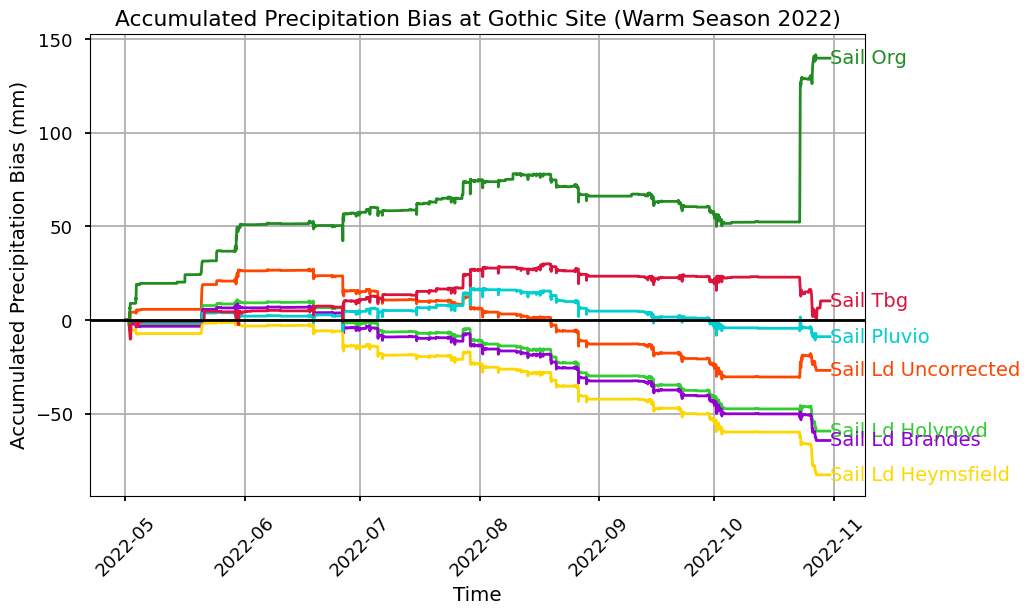

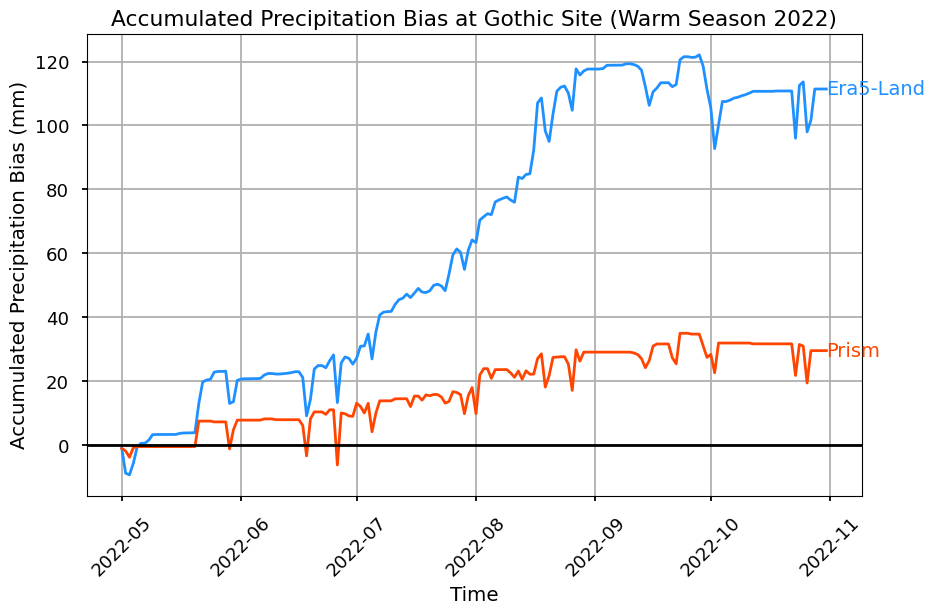

In [178]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [179]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_warm_season_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_warm_season_2023_prcp_accum.png


Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_warm_season_2023_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/gothic_gridded_warm_season_2023_prcp_bias.png


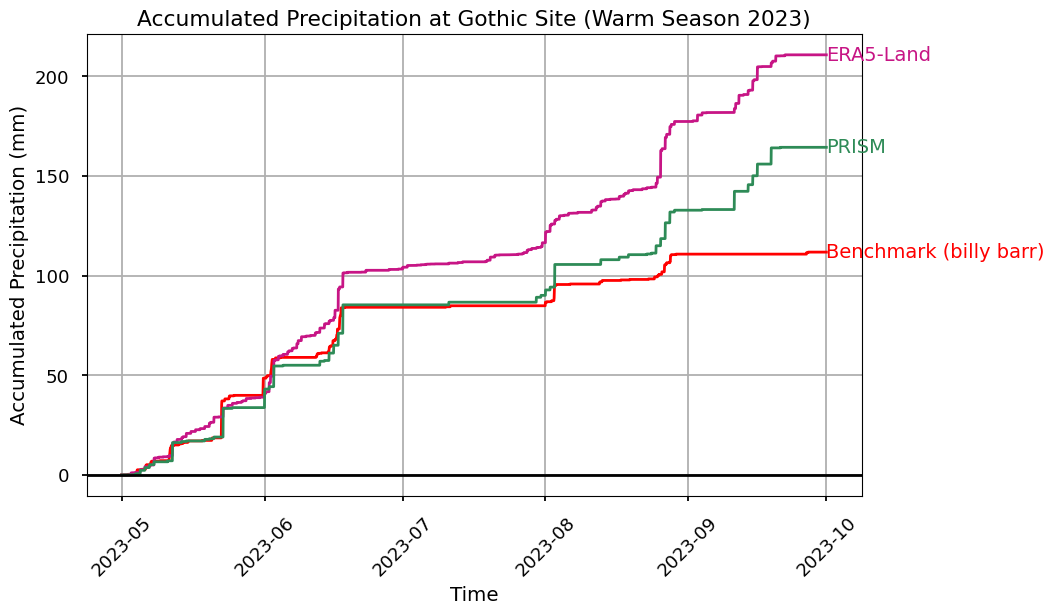

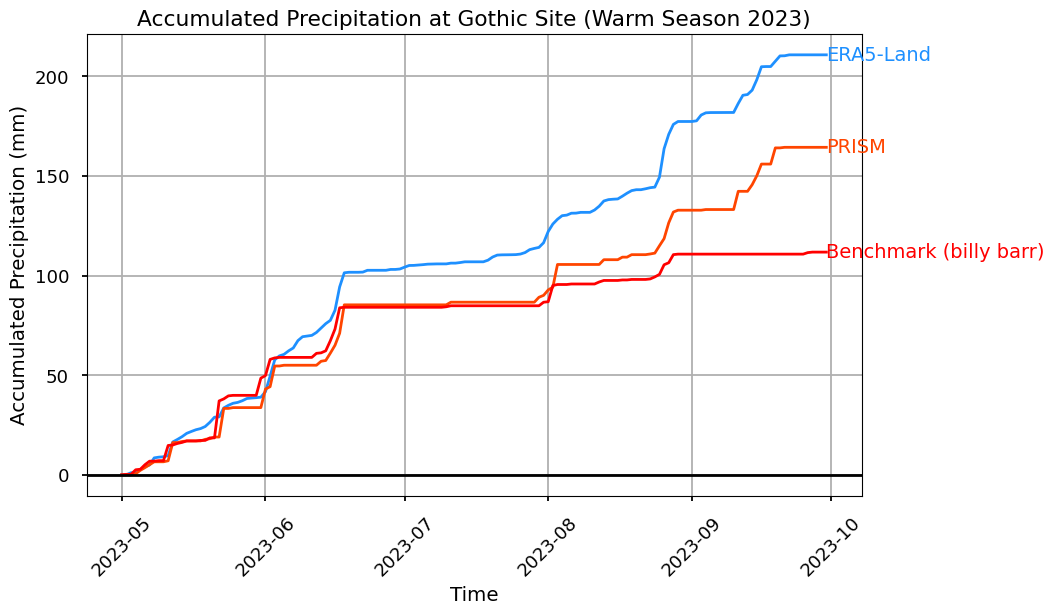

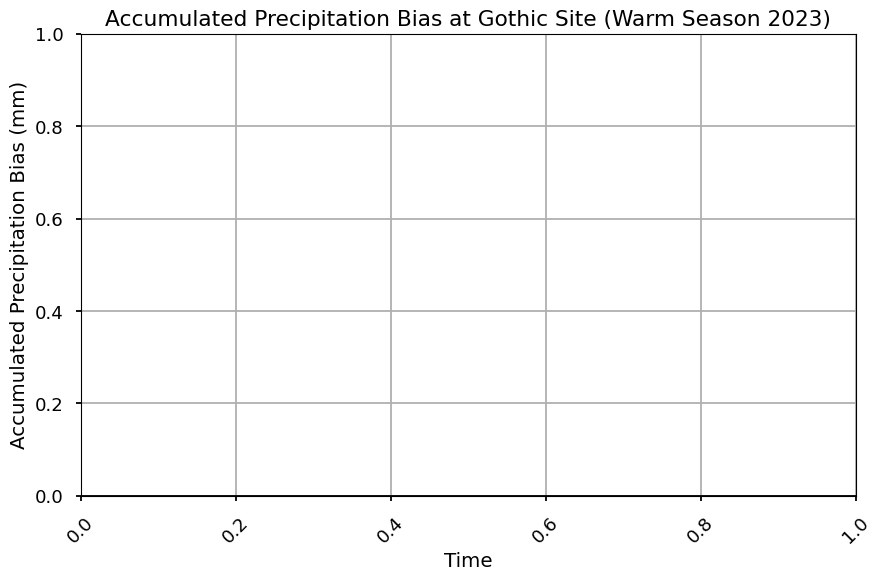

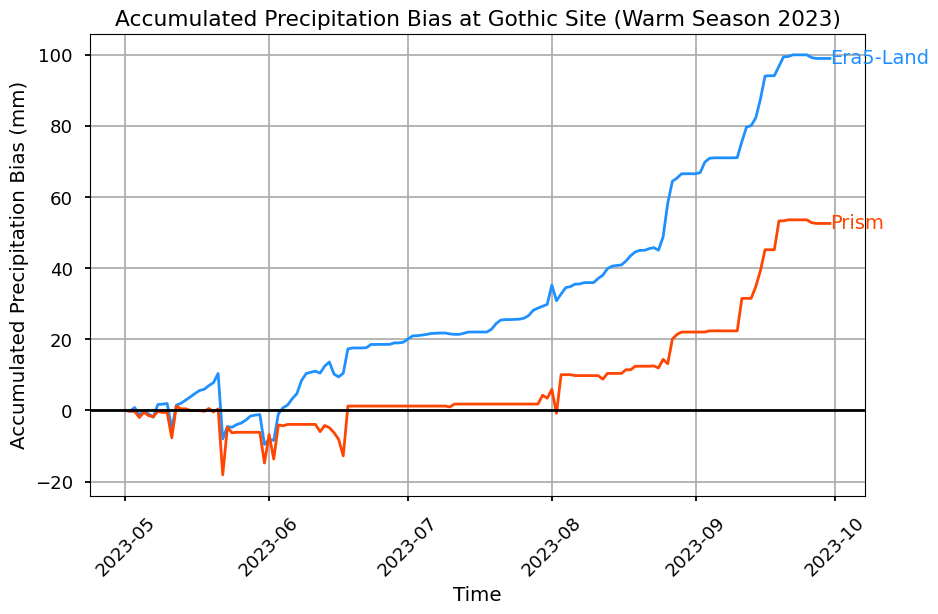

In [180]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

### Kettle Ponds

In [9]:
SITE = "kettle_ponds"

#### Cold Season (November - April)

In [10]:
ANALYSIS_TYPE = 'cold'  # options: 'all', 'warm', 'cold'

##### Water Year 2022

In [11]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_cold_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_cold_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_cold_season_2022_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_cold_season_2022_prcp_bias.png


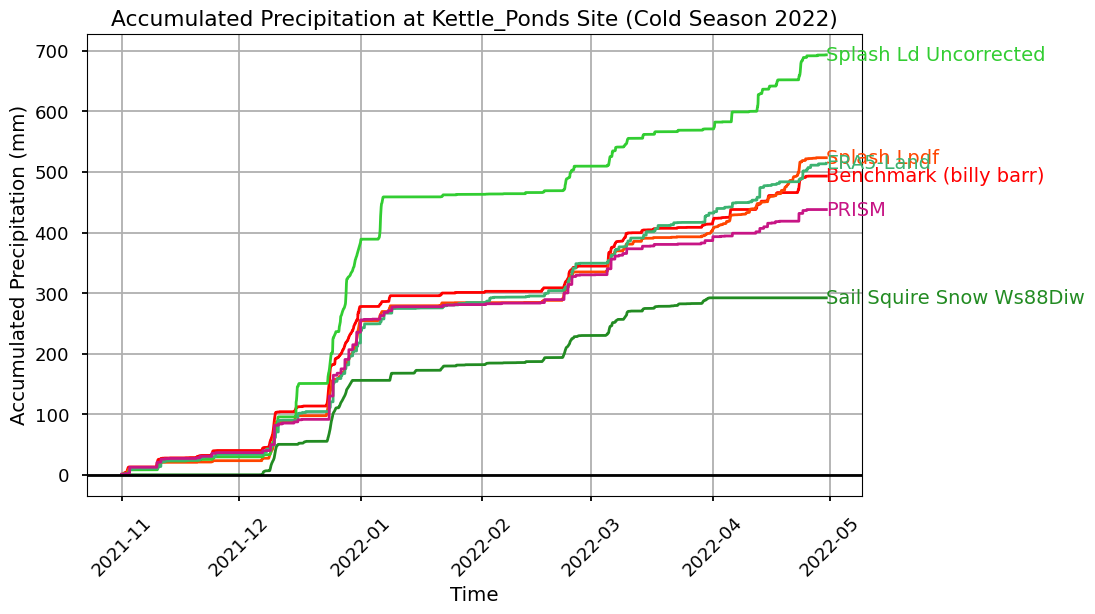

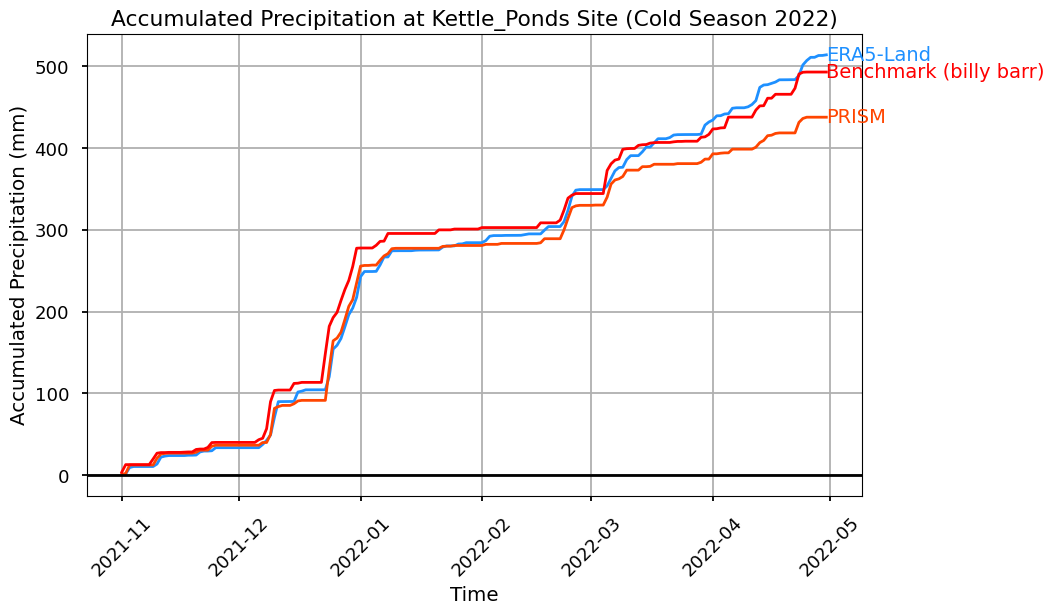

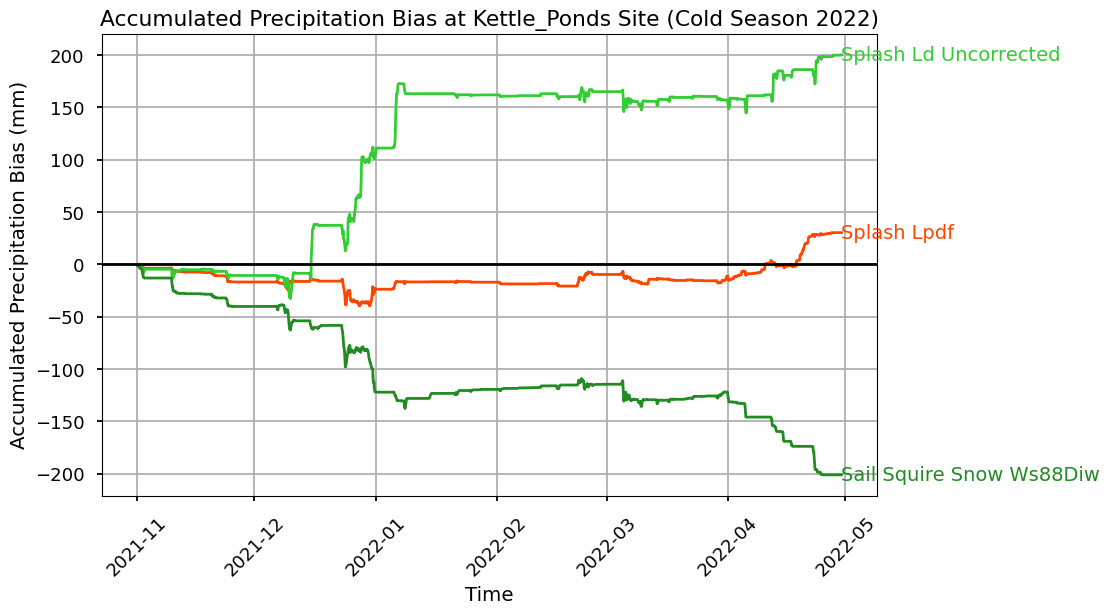

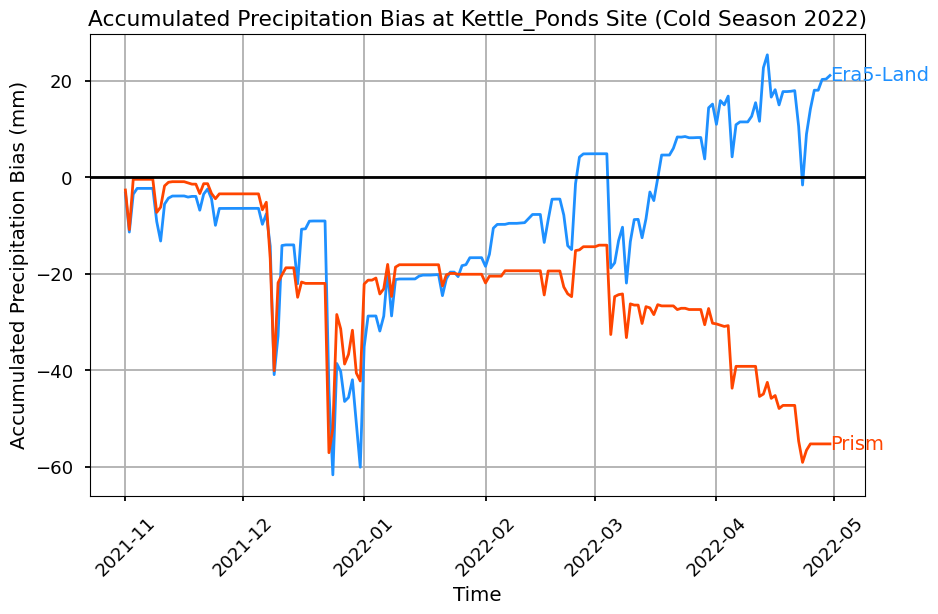

In [12]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

#### Winter

In [13]:
ANALYSIS_TYPE = 'DJF'  # options: 'all', 'warm', 'cold'

##### Water Year 2022

In [14]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_bias.png


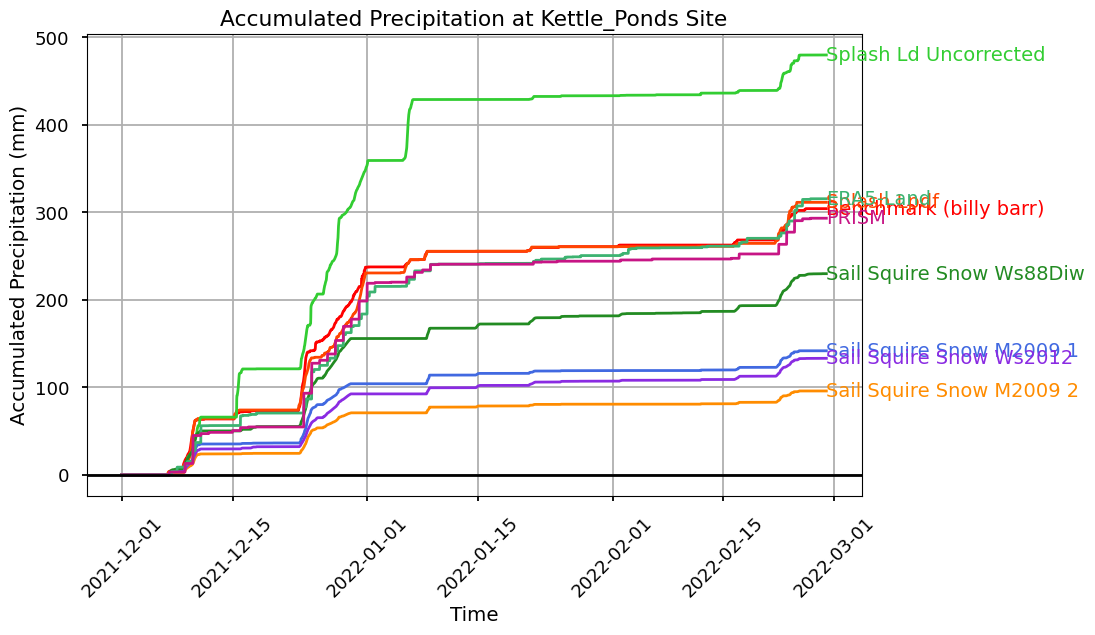

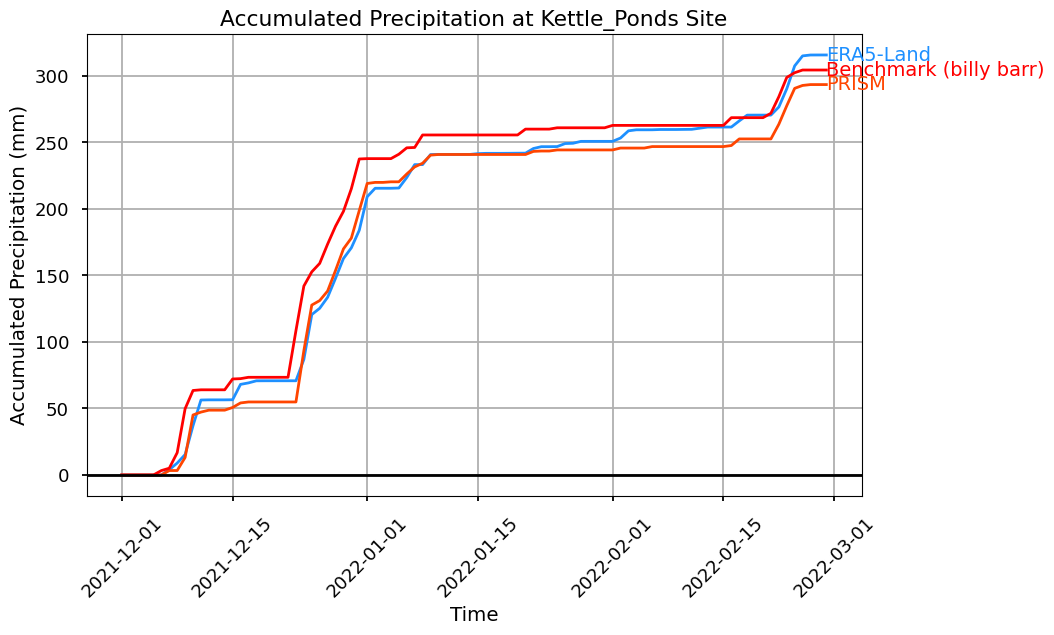

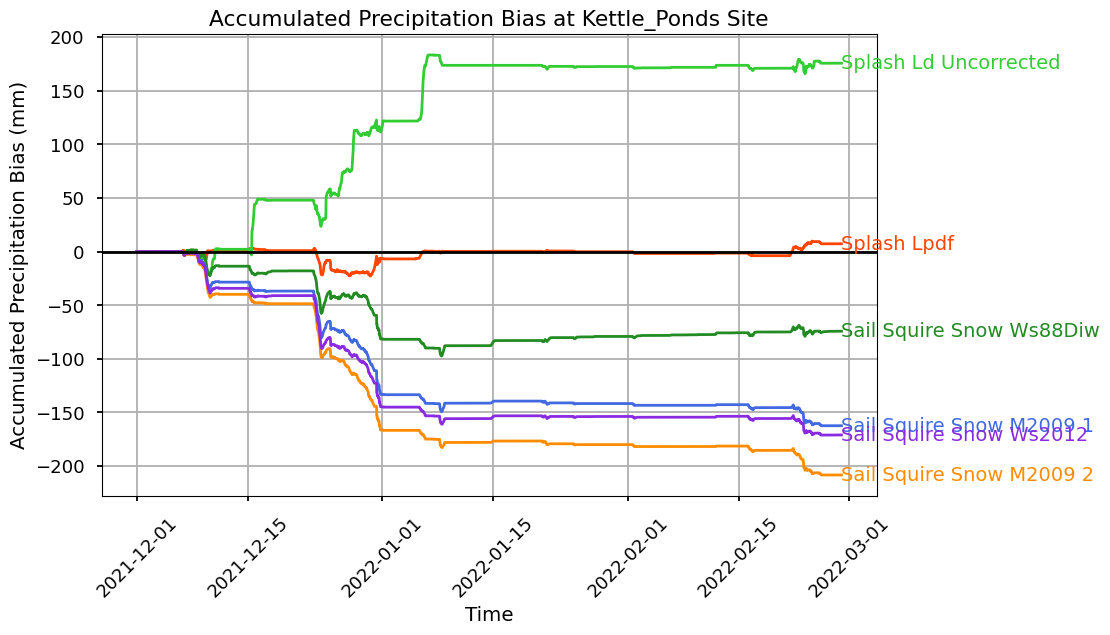

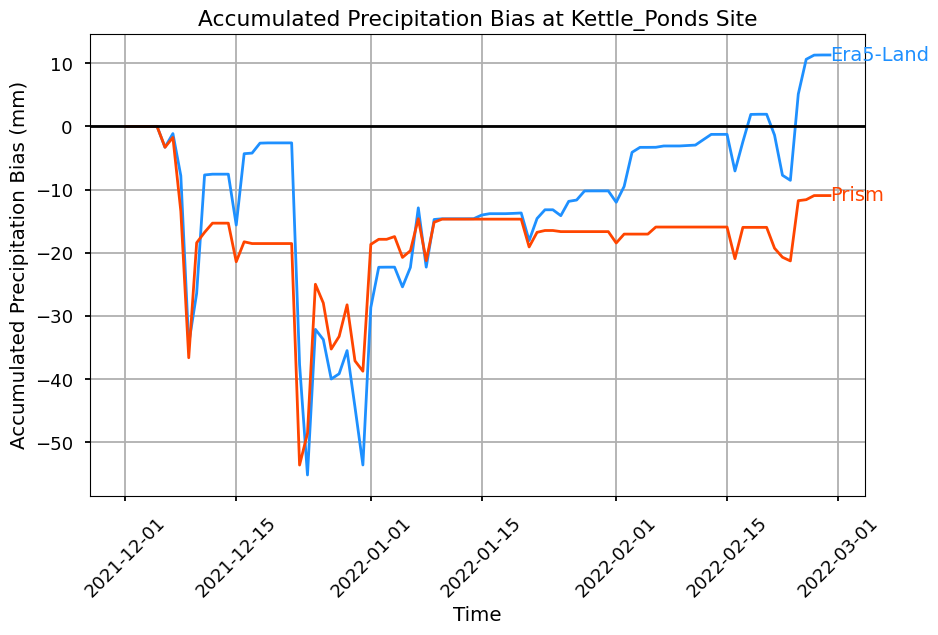

In [15]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [16]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_bias.png


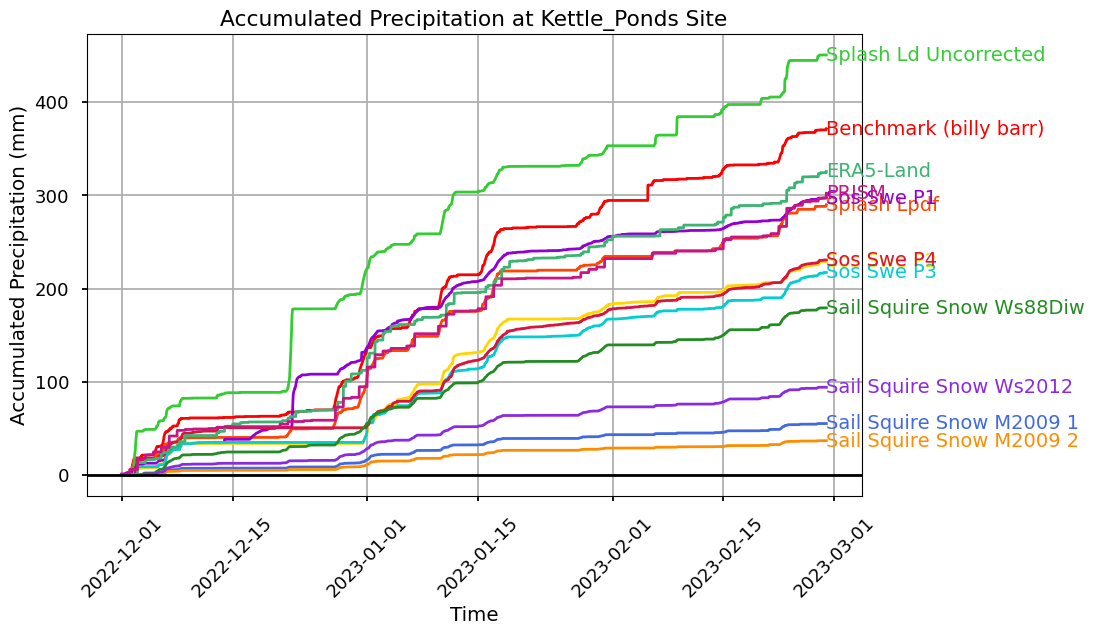

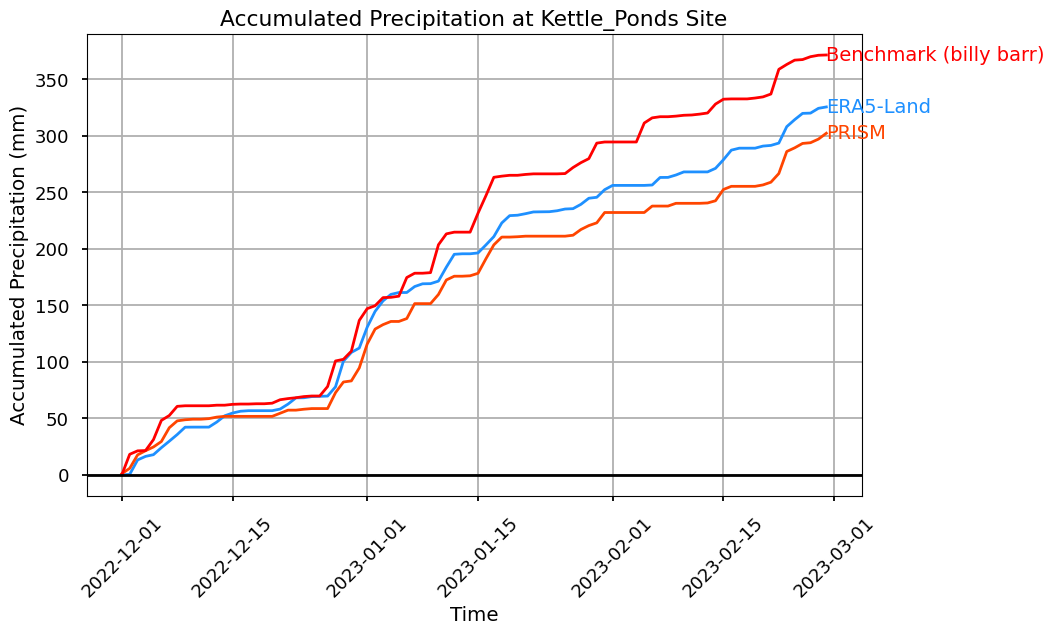

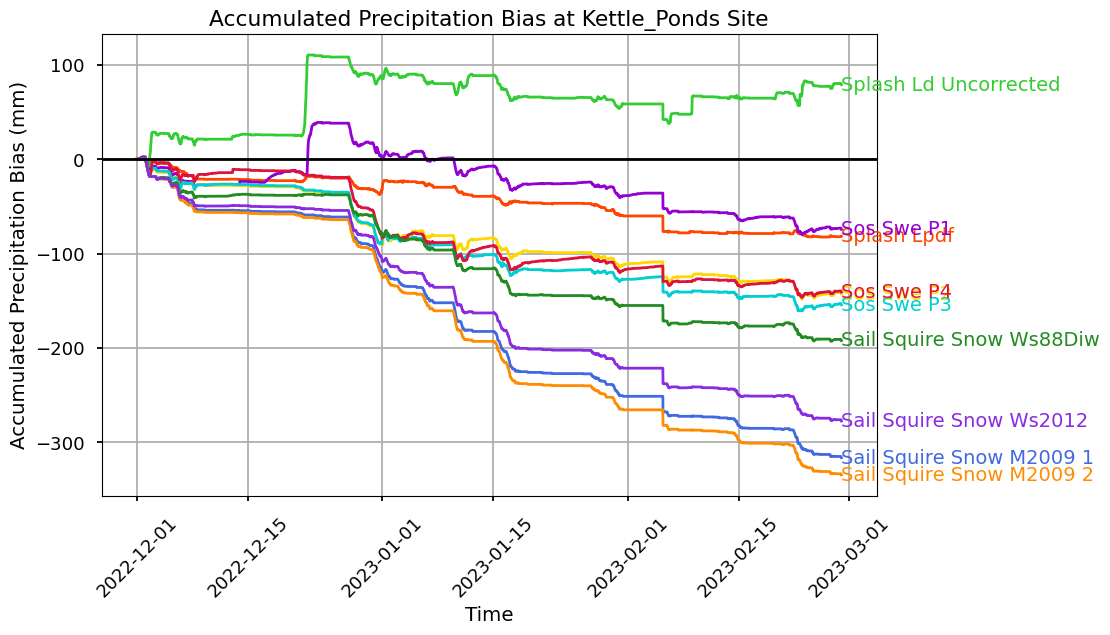

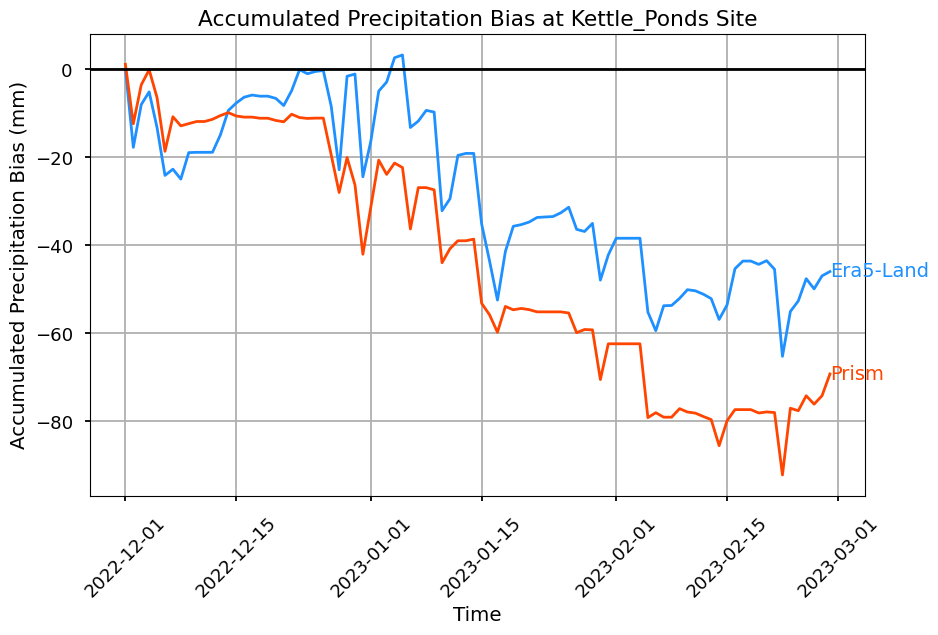

In [17]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

In [18]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_all_data_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_all_data_prcp_bias.png


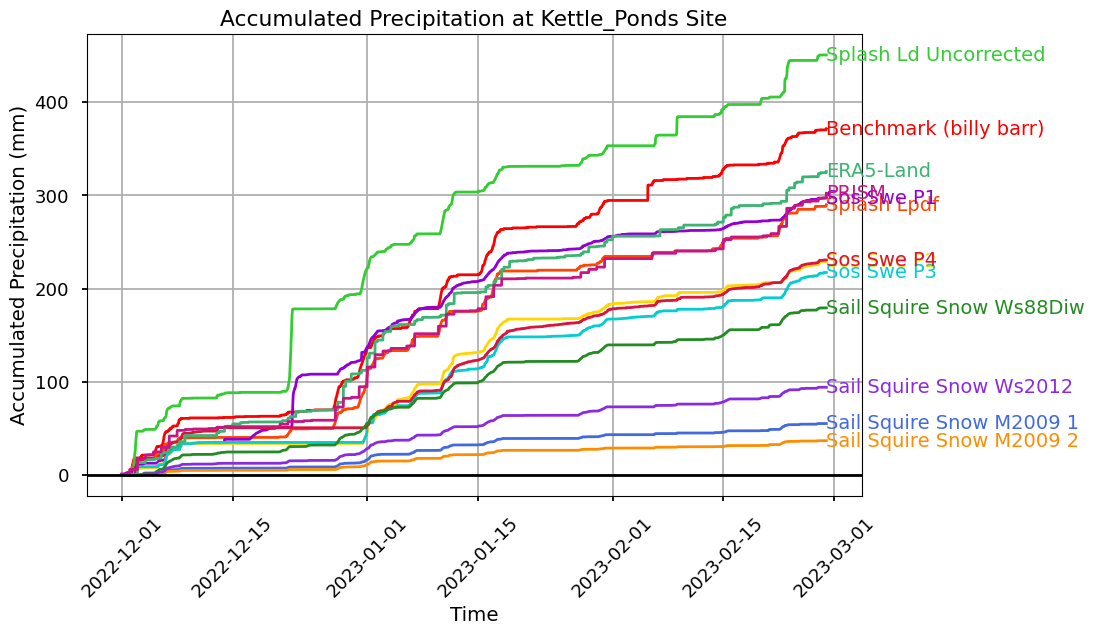

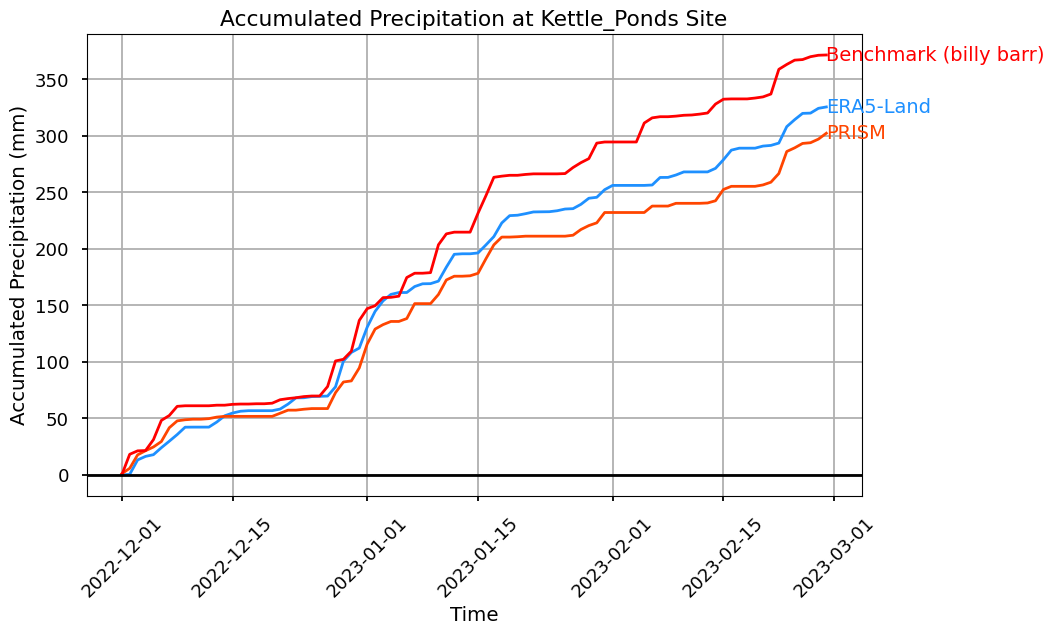

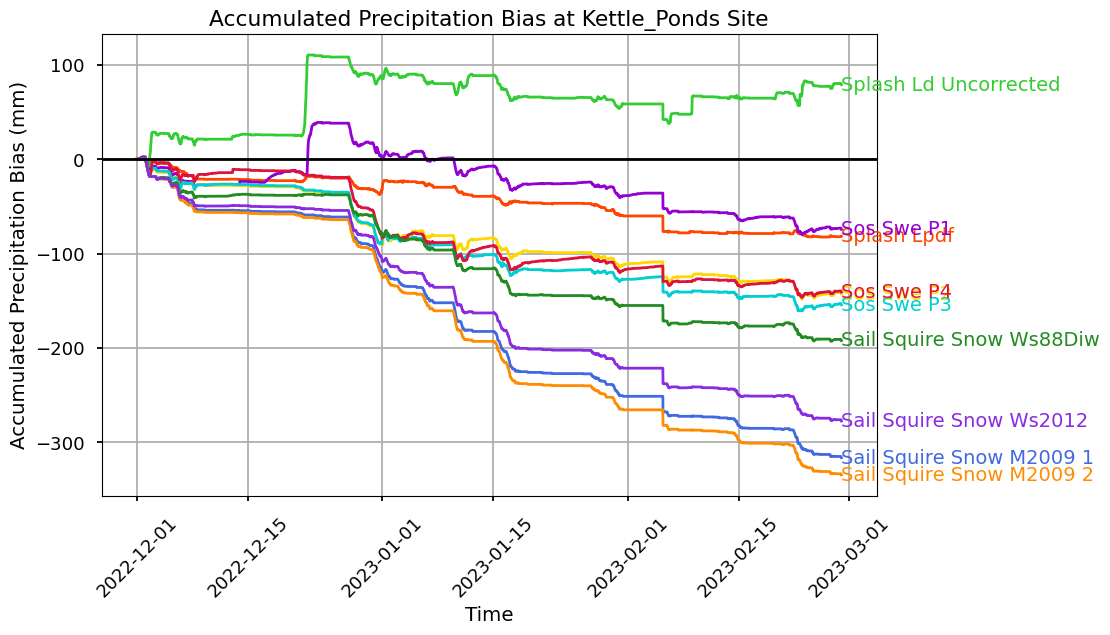

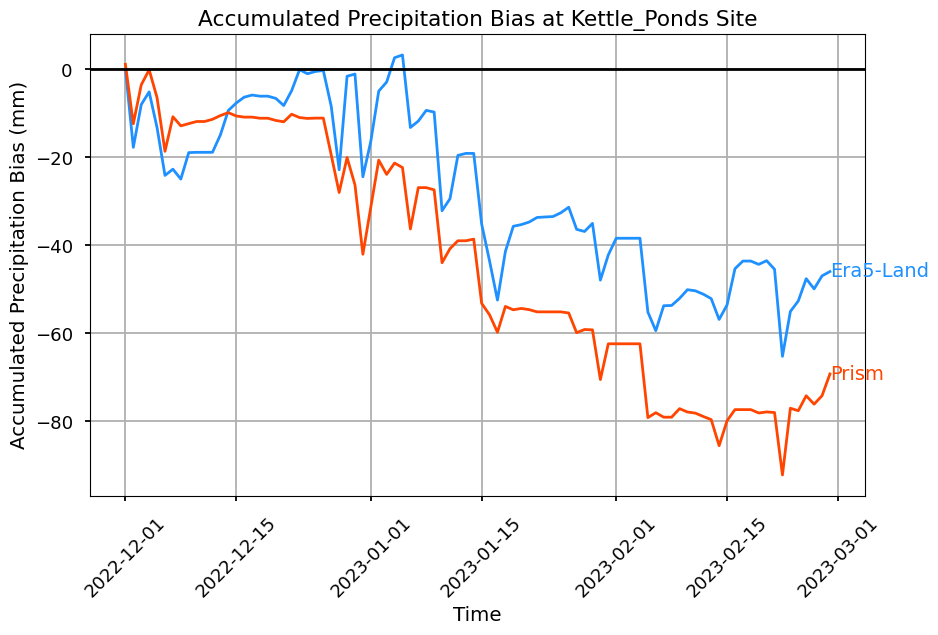

In [19]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

#### Warm Season (May - October)

In [20]:
ANALYSIS_TYPE = 'warm'  # options: 'all', 'warm', 'cold'

##### Water Year 2022

In [21]:
WATER_YEAR = 2022

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_warm_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_warm_season_2022_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_warm_season_2022_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_warm_season_2022_prcp_bias.png


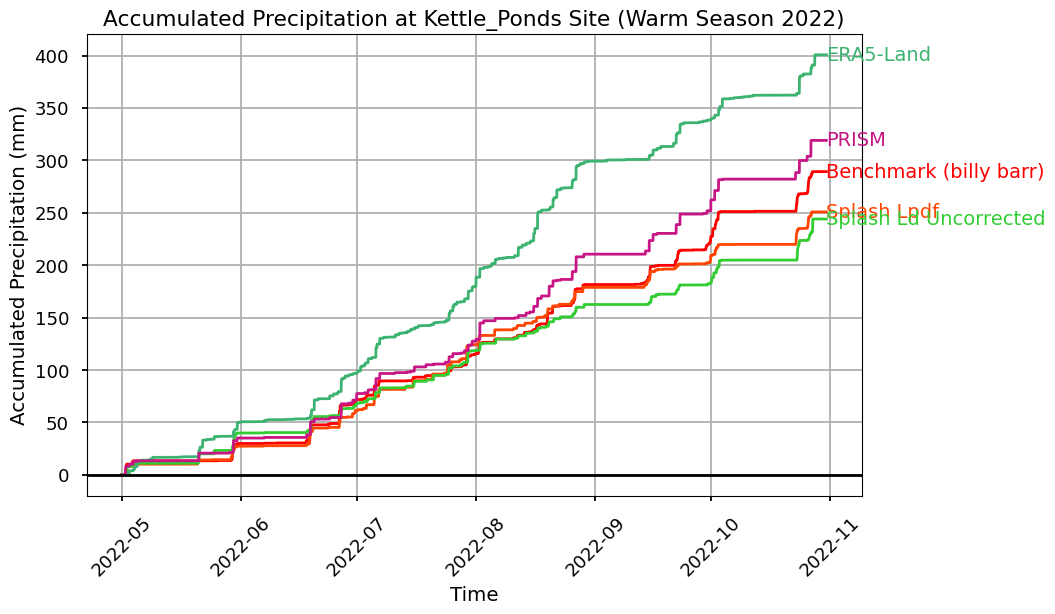

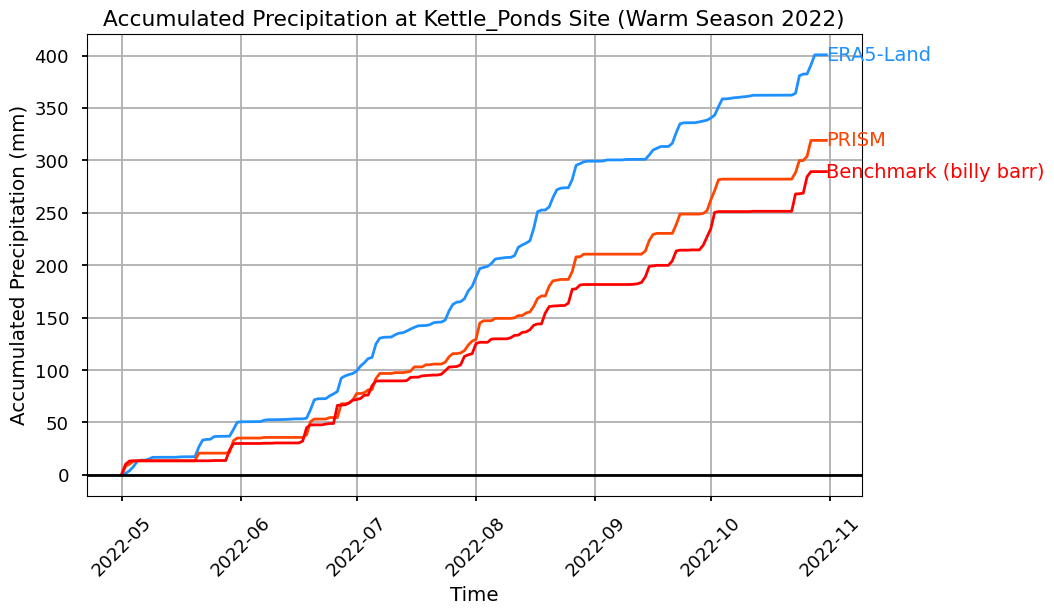

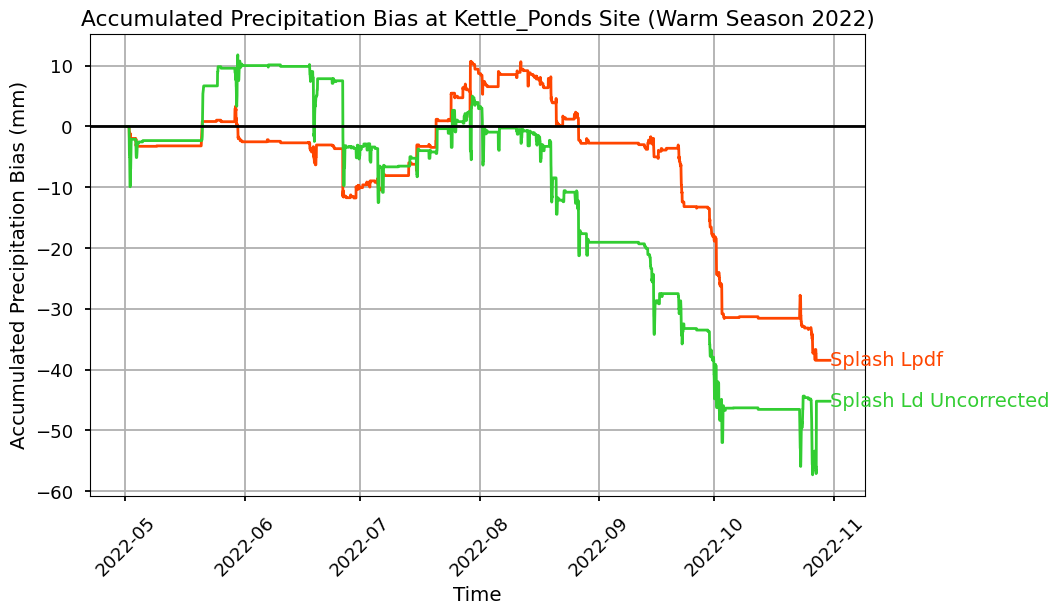

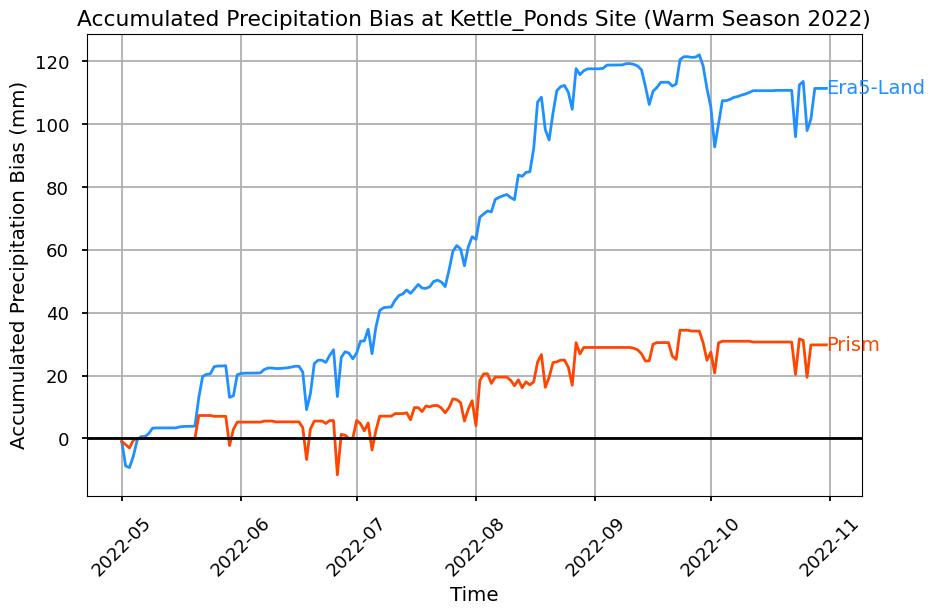

In [22]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

##### Water Year 2023

In [23]:
WATER_YEAR = 2023

gridded_vars = ['ERA5-Land','PRISM','billy_barr_precip']
original_ds = get_dataset(SITE, DATA_DIR)

# get time extents for all variables
time_slice = get_relevant_dates(original_ds, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
gridded_time_slice = get_relevant_dates(original_ds[gridded_vars], analysis_type=ANALYSIS_TYPE, gridded=True, water_year=WATER_YEAR)

# filter datasets to relevant time slices and drop bad/irrelevant vars
ds = drop_bad_or_irrelevant_vars(original_ds.sel(time=time_slice))
ds_gridded = drop_bad_or_irrelevant_vars(original_ds[gridded_vars].sel(time=gridded_time_slice).resample(time='1D').sum())

Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_warm_season_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_warm_season_2023_prcp_accum.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_warm_season_2023_prcp_bias.png
Figure saved to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/kettle_ponds_gridded_warm_season_2023_prcp_bias.png


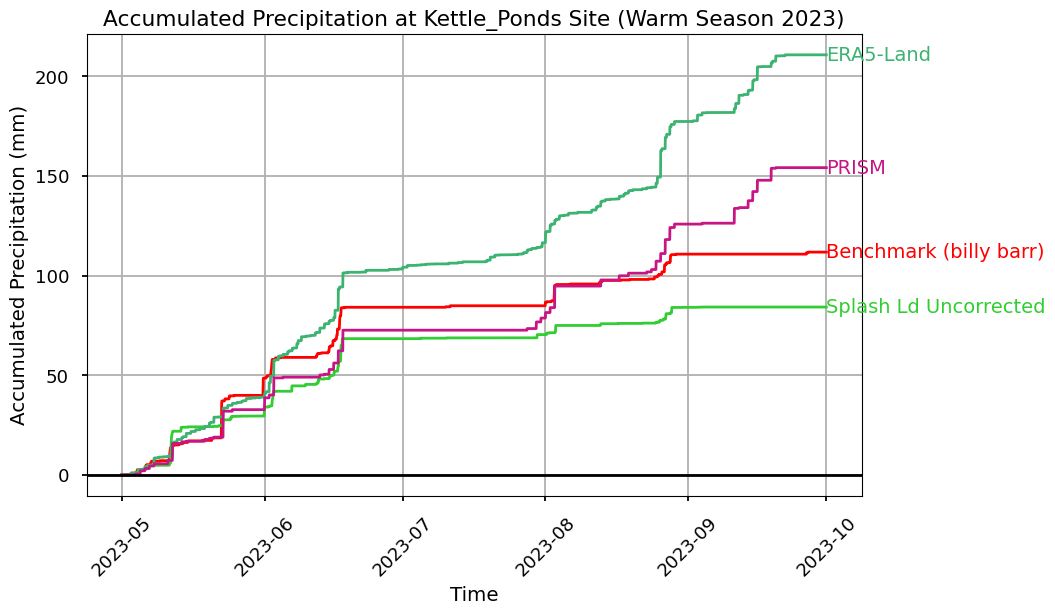

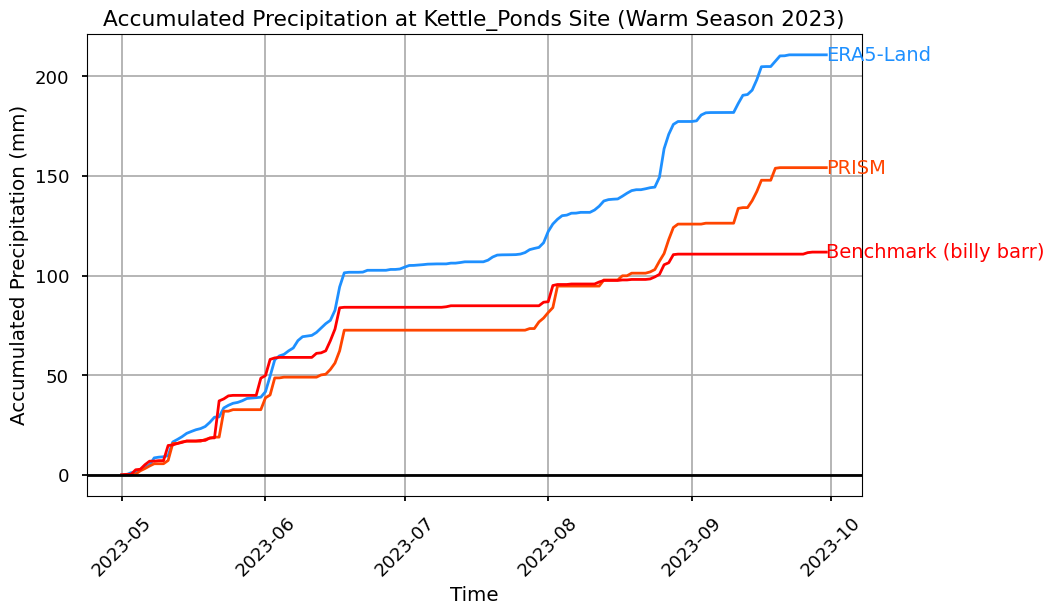

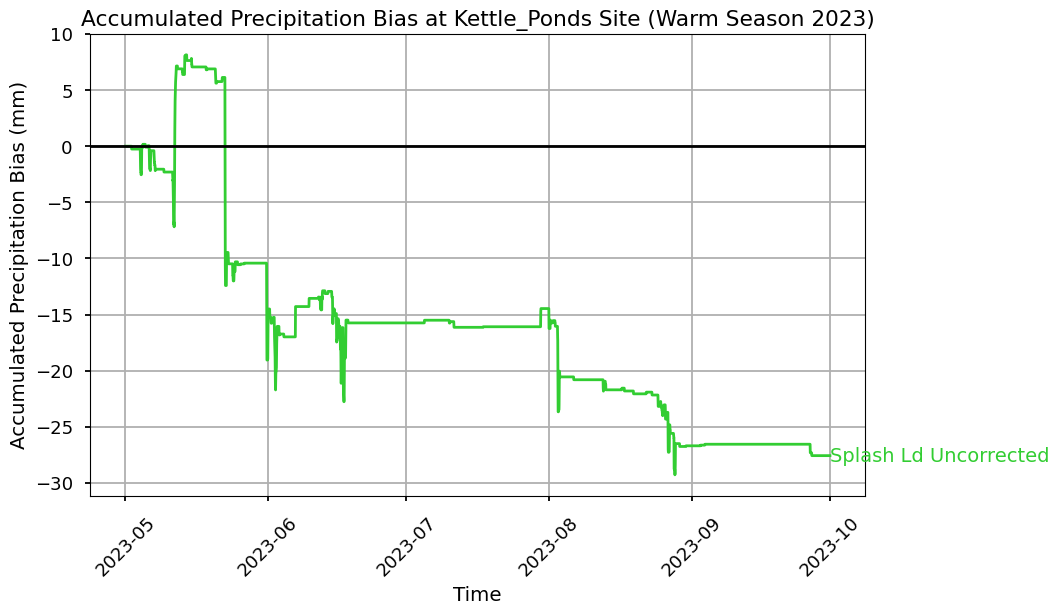

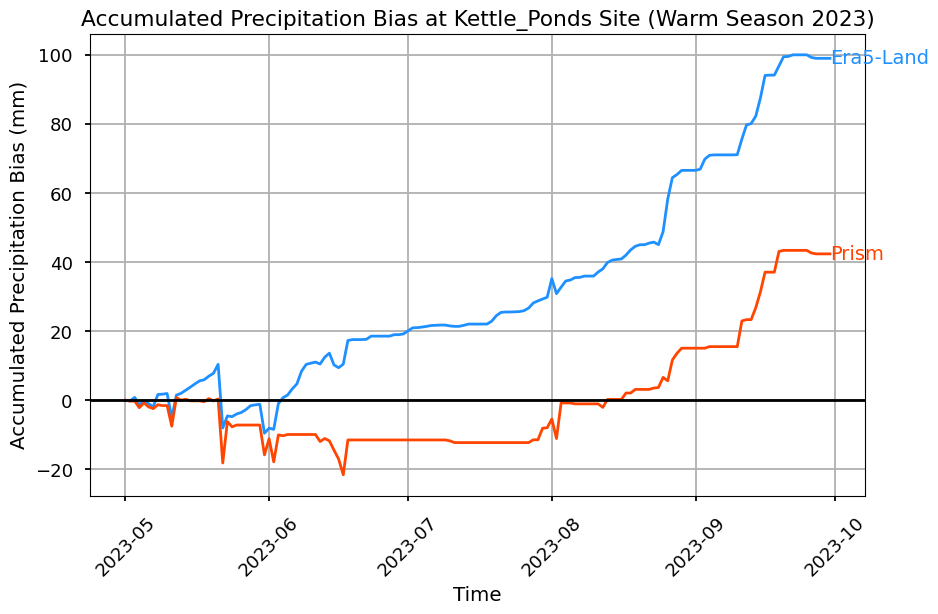

In [24]:
fig = plot_accumulated_precipitation(ds, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_precipitation(ds_gridded, plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='accum', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=False, output_dir=OUTPUT_DIR)

fig = plot_accumulated_bias(ds_gridded, benchmark='billy_barr_precip', plot_lib='plt', site=SITE, analysis_type=ANALYSIS_TYPE, water_year=WATER_YEAR, gridded=True)
save_figure(fig, SITE, ANALYSIS_TYPE, WATER_YEAR, plot_type='bias', plot_lib='plt', gridded=True, output_dir=OUTPUT_DIR)

In [25]:
# move all generated figures to more specific subdirectories

subdir_prcp = OUTPUT_DIR / "precipitation"
subdir_bias = OUTPUT_DIR / "bias"

for subdir in [subdir_prcp, subdir_bias]:
    if not os.path.exists(subdir):
        os.makedirs(subdir)
    subdir_gothic = subdir / "gothic"
    subdir_kettle = subdir / "kettle_ponds"
    for site_subdir in [subdir_gothic, subdir_kettle]:
        if not os.path.exists(site_subdir):
            os.makedirs(site_subdir)
for filename in os.listdir(OUTPUT_DIR):
    if filename.endswith(".png"):
        if "accum" in filename:
            dest_dir = subdir_prcp
        elif "bias" in filename:
            dest_dir = subdir_bias
        else:
            continue  # skip files that are not prcp or bias
        if "gothic" in filename:
            dest_dir = dest_dir / "gothic"
        elif "kettle_ponds" in filename:
            dest_dir = dest_dir / "kettle_ponds"
        else:
            continue  # skip files that are not for known sites
        src_path = os.path.join(OUTPUT_DIR, filename)
        dest_path = os.path.join(dest_dir, filename)
        os.rename(src_path, dest_path)
        print(f"Moved {filename} to {dest_dir}")

Moved gothic_gridded_warm_season_2023_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved gothic_warm_season_2023_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved gothic_2022_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved kettle_ponds_gridded_2022_prcp_bias.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/bias/kettle_ponds
Moved gothic_cold_season_2023_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved gothic_all_data_prcp_accum.png to /home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/accumulated/precipitation/gothic
Moved kettle_ponds_2023_prcp_bias.png to /home/dlhogan/projects/phd-repo